In [3]:
# Các thư viện cần thiết 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

Gộp 2 file thành 1 file

In [3]:
import pandas as pd

# Đọc hai file CSV
df1 = pd.read_csv('E-Commerce Customer Behavior Analysis/ecommerce_customer_behavior_dataset.csv')
df2 = pd.read_csv('E-Commerce Customer Behavior Analysis/ecommerce_customer_behavior_dataset_v2.csv')

ket_qua = pd.concat([df1, df2], ignore_index=True)

ket_qua.to_csv('E-Commerce Customer Behavior Analysis_full.csv', index=False)


In [6]:
sales = pd.read_csv("E-Commerce Customer Behavior Analysis_full.csv")

In [12]:
dirty = pd.read_csv("dirty_ecommerce_data.csv")
dirty.isna().sum()

Order_ID                       0
Customer_ID                    0
Date                           0
Age                         1000
Gender                         0
City                         800
Product_Category               0
Unit_Price                     0
Quantity                       0
Discount_Amount                0
Total_Amount                   0
Payment_Method               800
Device_Type                    0
Session_Duration_Minutes       0
Pages_Viewed                   0
Is_Returning_Customer          0
Delivery_Time_Days           600
Customer_Rating             1000
dtype: int64

In [14]:
ket_qua_add_dirty = pd.concat([sales, dirty], ignore_index=True)
ket_qua_add_dirty.to_csv('ECM_dirty.csv', index=False)

In [340]:
df = pd.read_csv("ECM_dirty.csv")

In [342]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24049 entries, 0 to 24048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  24049 non-null  object 
 1   Customer_ID               24049 non-null  object 
 2   Date                      24049 non-null  object 
 3   Age                       23049 non-null  float64
 4   Gender                    24049 non-null  object 
 5   City                      23249 non-null  object 
 6   Product_Category          24049 non-null  object 
 7   Unit_Price                24049 non-null  float64
 8   Quantity                  24049 non-null  int64  
 9   Discount_Amount           24049 non-null  float64
 10  Total_Amount              24049 non-null  float64
 11  Payment_Method            23249 non-null  object 
 12  Device_Type               24049 non-null  object 
 13  Session_Duration_Minutes  24049 non-null  int64  
 14  Pages_

In [25]:
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,23049.000000,24049.000000,24049.000000,24049.000000,24049.000000,24049.000000,24049.000000,23449.000000,23049.000000
mean,35.004252,436.240238,2.762734,59.408788,1133.184422,15.434530,8.915755,6.373790,3.880949
std,10.904956,696.643174,1.494364,209.385654,2185.373474,10.395648,2.621113,3.474334,1.132442
min,18.000000,5.050000,1.000000,0.000000,6.210000,1.000000,1.000000,1.000000,1.000000
25%,27.000000,68.440000,1.000000,0.000000,159.800000,11.000000,7.000000,4.000000,3.000000
50%,35.000000,177.110000,3.000000,0.000000,391.850000,14.000000,9.000000,6.000000,4.000000
75%,42.000000,499.360000,4.000000,25.080000,1067.120000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,78.000000,24.000000,25.000000,5.000000


In [27]:
df.isnull().sum()

Order_ID                       0
Customer_ID                    0
Date                           0
Age                         1000
Gender                         0
City                         800
Product_Category               0
Unit_Price                     0
Quantity                       0
Discount_Amount                0
Total_Amount                   0
Payment_Method               800
Device_Type                    0
Session_Duration_Minutes       0
Pages_Viewed                   0
Is_Returning_Customer          0
Delivery_Time_Days           600
Customer_Rating             1000
dtype: int64

Xu ly du lieu bi thieu

In [30]:
print("Ty le du lieu bi thieu trong dataset")
df.isna().mean()

Ty le du lieu bi thieu trong dataset


Order_ID                    0.000000
Customer_ID                 0.000000
Date                        0.000000
Age                         0.041582
Gender                      0.000000
City                        0.033265
Product_Category            0.000000
Unit_Price                  0.000000
Quantity                    0.000000
Discount_Amount             0.000000
Total_Amount                0.000000
Payment_Method              0.033265
Device_Type                 0.000000
Session_Duration_Minutes    0.000000
Pages_Viewed                0.000000
Is_Returning_Customer       0.000000
Delivery_Time_Days          0.024949
Customer_Rating             0.041582
dtype: float64

In [32]:
# Tỉ lệ dữ liệu bị thiếu theo dạng %
# Giả sử dataframe của bạn tên là df
missing_data = df.isnull().mean() * 100
missing_data_filtered = missing_data[missing_data > 0].sort_values(ascending=False)

print(missing_data_filtered.map("{:.2f}%".format))

Age                   4.16%
Customer_Rating       4.16%
City                  3.33%
Payment_Method        3.33%
Delivery_Time_Days    2.49%
dtype: object


# Xet du ly du lieu bi thieu trong cot Age 

Thong ke xem age co bao nhieu du lieu NaN

In [344]:
df[df["Age"].isna()]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
22050,ORD_004885,CUST_04885,2023-01-01,NaN,Male,Konya,Toys,244.90,1,0.00,244.90,NaN,Mobile,11,3,True,3.0,NaN
22051,ORD_004507,CUST_04507,2023-01-01,NaN,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,5.0,2.0
22052,ORD_000645,CUST_00645,2023-01-01,NaN,Male,Istanbul,Electronics,804.06,1,229.28,574.78,NaN,Mobile,8,10,False,1.0,NaN
22056,ORD_000645,CUST_00645,2023-01-01,NaN,Male,NaN,Electronics,804.06,1,229.28,574.78,NaN,Mobile,8,10,False,1.0,4.0
22058,ORD_004885,CUST_04885,2023-01-01,NaN,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24033,ORD_001337,CUST_01337,2023-01-01,NaN,Female,NaN,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,NaN,NaN
24036,ORD_000645,CUST_00645,2023-01-01,NaN,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1.0,NaN
24041,ORD_001337,CUST_01337,2023-01-01,NaN,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8.0,NaN
24042,ORD_004885,CUST_04885,2023-01-01,NaN,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3.0,3.0


In [346]:
num_miss_age = df["Age"].isna().sum()
print(f"Tổng dữ liệu bị thiếu trong cột Age là: {num_miss_age} trên tổng số 24049 dòng dữ liệu của cả dataset")

Tổng dữ liệu bị thiếu trong cột Age là: 1000 trên tổng số 24049 dòng dữ liệu của cả dataset


In [348]:
median_of_age = df["Age"].median()
print(f"Gia tri median cua Age la: {median_of_age}")

Gia tri median cua Age la: 35.0


In [350]:
df["Median_Age"] = df["Age"].fillna(median_of_age)

In [352]:
mean_of_age = df["Age"].mean()
print(f"Gia tri mean cua Age la: {mean_of_age}")

Gia tri mean cua Age la: 35.00425181135841


In [354]:
df["Mean_Age"] = df["Age"].fillna(mean_of_age)

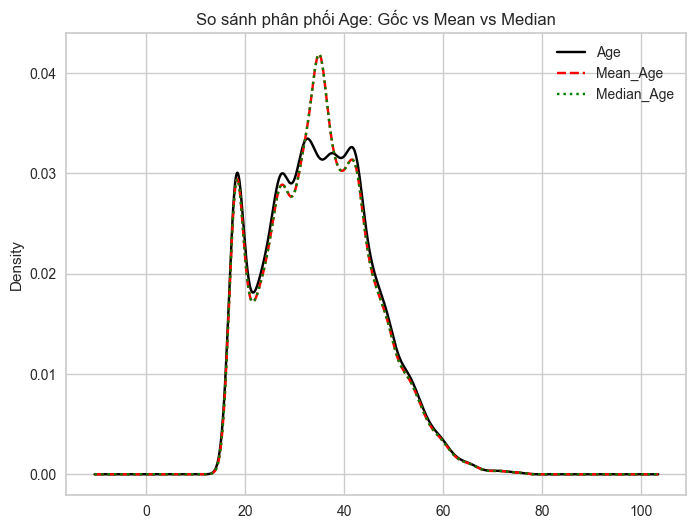

In [356]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [8,6]
fig = plt.figure()
ax = fig.add_subplot(111)
# Vẽ biểu đồ KDE 
df['Age'].plot(kind='kde', ax=ax, color='black')
df['Mean_Age'].plot(kind='kde', ax=ax, color='red', linestyle='--')
df['Median_Age'].plot(kind='kde', ax=ax, color='green', linestyle=':')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')
plt.title('So sánh phân phối Age: Gốc vs Mean vs Median')
plt.show()

In [357]:
df["Age"] = df["Age"].fillna(median_of_age)

In [358]:
df["Age"].isna().sum()

np.int64(0)

In [362]:
df.drop(columns=["Median_Age", "Mean_Age"], axis = 1, inplace = True)

In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24049 entries, 0 to 24048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  24049 non-null  object 
 1   Customer_ID               24049 non-null  object 
 2   Date                      24049 non-null  object 
 3   Age                       24049 non-null  float64
 4   Gender                    24049 non-null  object 
 5   City                      23249 non-null  object 
 6   Product_Category          24049 non-null  object 
 7   Unit_Price                24049 non-null  float64
 8   Quantity                  24049 non-null  int64  
 9   Discount_Amount           24049 non-null  float64
 10  Total_Amount              24049 non-null  float64
 11  Payment_Method            23249 non-null  object 
 12  Device_Type               24049 non-null  object 
 13  Session_Duration_Minutes  24049 non-null  int64  
 14  Pages_

# Xử lý dữ liệu thiếu trong cột city

In [367]:
df[df["City"].isna()]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
22053,ORD_001337,CUST_01337,2023-01-01,27.0,Female,NaN,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,NaN,5.0
22056,ORD_000645,CUST_00645,2023-01-01,35.0,Male,NaN,Electronics,804.06,1,229.28,574.78,NaN,Mobile,8,10,False,1.0,4.0
22057,ORD_001337,CUST_01337,2023-01-01,27.0,Female,NaN,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,8.0,5.0
22059,ORD_004507,CUST_04507,2023-01-01,35.0,Female,NaN,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,5.0,NaN
22061,ORD_001337,CUST_01337,2023-01-01,27.0,Female,NaN,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24043,ORD_004507,CUST_04507,2023-01-01,43.0,Female,NaN,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,5.0,2.0
24045,ORD_001337,CUST_01337,2023-01-01,27.0,Female,NaN,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,8.0,NaN
24046,ORD_004885,CUST_04885,2023-01-01,42.0,Male,NaN,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3.0,3.0
24047,ORD_004507,CUST_04507,2023-01-01,35.0,Female,NaN,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,5.0,NaN


In [369]:
num_miss_city = df["City"].isna().sum()

In [370]:
print(f"Tổng giá trị NaN của City là: {num_miss_city} trên tổng số 22449 dòng dữ liệu của cả dataset")

Tổng giá trị NaN của City là: 800 trên tổng số 22449 dòng dữ liệu của cả dataset


In [371]:
mode_of_city = df["City"].mode()
print(f"Gia tri mode cua City la: {mode_of_city[0]}")

Gia tri mode cua City la: Istanbul


In [372]:
df["City"] = df["City"].fillna(mode_of_city[0])

In [373]:
df["City"].isna().sum()

np.int64(0)

In [374]:
df[df["City"].isna()]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating


# Xử lý dữ liệu thiếu trong cột Payment_Method

In [382]:
df[df["Payment_Method"].isna()]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
22049,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Bursa,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,NaN,5.0
22050,ORD_004885,CUST_04885,2023-01-01,35.0,Male,Konya,Toys,244.90,1,0.00,244.90,NaN,Mobile,11,3,True,3.0,NaN
22052,ORD_000645,CUST_00645,2023-01-01,35.0,Male,Istanbul,Electronics,804.06,1,229.28,574.78,NaN,Mobile,8,10,False,1.0,NaN
22053,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Istanbul,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,NaN,5.0
22054,ORD_004885,CUST_04885,2023-01-01,42.0,Male,Konya,Toys,244.90,1,0.00,244.90,NaN,Mobile,11,3,True,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24037,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Bursa,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,8.0,NaN
24039,ORD_004507,CUST_04507,2023-01-01,43.0,Female,Istanbul,Food,48.15,5,0.00,240.75,NaN,Mobile,78,5,True,5.0,2.0
24044,ORD_000645,CUST_00645,2023-01-01,32.0,Male,Istanbul,Electronics,804.06,1,229.28,574.78,NaN,Mobile,8,10,False,1.0,NaN
24045,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Istanbul,Toys,54.28,1,0.00,54.28,NaN,Mobile,4,14,True,8.0,NaN


In [384]:
num_miss_payment_method = df["Payment_Method"].isna().sum()

In [386]:
print(f"Tổng giá trị NaN của Payment_Method là: {num_miss_payment_method} trên tổng số 22449 dòng dữ liệu của cả dataset")

Tổng giá trị NaN của Payment_Method là: 800 trên tổng số 22449 dòng dữ liệu của cả dataset


In [388]:
mode_of_payment =  df["Payment_Method"].mode()[0]
print(f"Gia tri mode cua Payment_Method la: {mode_of_payment}")

Gia tri mode cua Payment_Method la: Credit Card


In [390]:
df["Payment_Method"] = df["Payment_Method"].fillna(mode_of_payment)

In [392]:
df["Payment_Method"].isna().sum()

np.int64(0)

# Xử lý dữ liệu bị thiếu Delivery_Time_Days

In [395]:
df[df["Delivery_Time_Days"].isna()]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
22049,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Bursa,Toys,54.28,1,0.00,54.28,Credit Card,Mobile,4,14,True,NaN,5.0
22053,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Istanbul,Toys,54.28,1,0.00,54.28,Credit Card,Mobile,4,14,True,NaN,5.0
22054,ORD_004885,CUST_04885,2023-01-01,42.0,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,NaN,3.0
22060,ORD_000645,CUST_00645,2023-01-01,32.0,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,NaN,4.0
22066,ORD_004885,CUST_04885,2023-01-01,35.0,Male,Istanbul,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24032,ORD_000645,CUST_00645,2023-01-01,32.0,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,NaN,4.0
24033,ORD_001337,CUST_01337,2023-01-01,35.0,Female,Istanbul,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,NaN,NaN
24034,ORD_004885,CUST_04885,2023-01-01,42.0,Male,Istanbul,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,NaN,3.0
24035,ORD_004507,CUST_04507,2023-01-01,43.0,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,NaN,2.0


In [397]:
num_miss_delivery_times = df["Delivery_Time_Days"].isna().sum()

In [399]:
print(f"Tổng giá trị NaN của Delivery_Time_Days là: {num_miss_delivery_times} trên tổng số 22449 dòng dữ liệu của cả dataset")

Tổng giá trị NaN của Delivery_Time_Days là: 600 trên tổng số 22449 dòng dữ liệu của cả dataset


In [401]:
median_of_delivery = df["Delivery_Time_Days"].median()
print(f"Gia tri median cua Delivery_Time_Days la: {median_of_delivery}")

Gia tri median cua Delivery_Time_Days la: 6.0


In [403]:
df["Median_Delivery_Time_Days"] = df["Delivery_Time_Days"].fillna(median_of_delivery)

In [405]:
mean_of_delivery = df["Delivery_Time_Days"].mean()
print(f"Gia tri mean cua Delivery_Time_Days la: {mean_of_delivery}")

Gia tri mean cua Delivery_Time_Days la: 6.373789927075782


In [407]:
df["Mean_Delivery_Time_Days"] = df["Delivery_Time_Days"].fillna(mean_of_delivery)

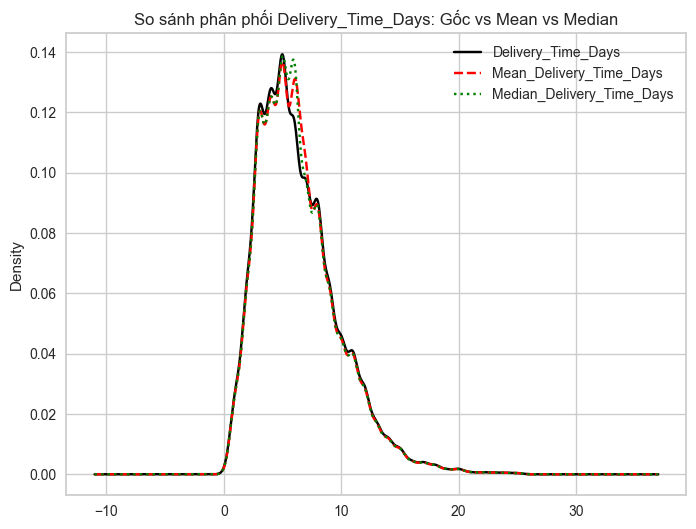

In [409]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [8,6]
fig = plt.figure()
ax = fig.add_subplot(111)
# Vẽ biểu đồ KDE 
df['Delivery_Time_Days'].plot(kind='kde', ax=ax, color='black')
df['Mean_Delivery_Time_Days'].plot(kind='kde', ax=ax, color='red', linestyle='--')
df['Median_Delivery_Time_Days'].plot(kind='kde', ax=ax, color='green', linestyle=':')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')
plt.title('So sánh phân phối Delivery_Time_Days: Gốc vs Mean vs Median')
plt.show()

In [412]:
df["Delivery_Time_Days"] = df["Delivery_Time_Days"].fillna(median_of_delivery)

In [414]:
df["Delivery_Time_Days"].isna().sum()

np.int64(0)

In [416]:
df.drop(columns=["Mean_Delivery_Time_Days", "Median_Delivery_Time_Days"], axis = 1, inplace = True)

# Xừ lý dữ liệu bị thiếu trong cột Customer_Rating

In [419]:
df[df["Customer_Rating"].isna()]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
22050,ORD_004885,CUST_04885,2023-01-01,35.0,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3.0,NaN
22052,ORD_000645,CUST_00645,2023-01-01,35.0,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1.0,NaN
22055,ORD_004507,CUST_04507,2023-01-01,43.0,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,5.0,NaN
22058,ORD_004885,CUST_04885,2023-01-01,35.0,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3.0,NaN
22059,ORD_004507,CUST_04507,2023-01-01,35.0,Female,Istanbul,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24041,ORD_001337,CUST_01337,2023-01-01,35.0,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8.0,NaN
24044,ORD_000645,CUST_00645,2023-01-01,32.0,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1.0,NaN
24045,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Istanbul,Toys,54.28,1,0.00,54.28,Credit Card,Mobile,4,14,True,8.0,NaN
24047,ORD_004507,CUST_04507,2023-01-01,35.0,Female,Istanbul,Food,48.15,5,0.00,240.75,Credit Card,Mobile,78,5,True,5.0,NaN


In [421]:
num_miss_Customer_Rating = df["Customer_Rating"].isna().sum()

In [423]:
print(f"Tổng giá trị NaN của Customer_Rating là: {num_miss_Customer_Rating} trên tổng số 22449 dòng dữ liệu của cả dataset")

Tổng giá trị NaN của Customer_Rating là: 1000 trên tổng số 22449 dòng dữ liệu của cả dataset


In [425]:
rating_mean = round(df["Customer_Rating"].mean(), 1)
print(f"Gia tri mean cua Customer_Rating la: {rating_mean}")

Gia tri mean cua Customer_Rating la: 3.9


In [427]:
df["Mean_Customer_Rating"] = df["Customer_Rating"].fillna(rating_mean)

In [429]:
rating_median = round(df["Customer_Rating"].median(), 1)
print(f"Gia tri median cua Customer_Rating la: {rating_median}")

Gia tri median cua Customer_Rating la: 4.0


In [431]:
df["Median_Customer_Rating"] = df["Customer_Rating"].fillna(rating_median)

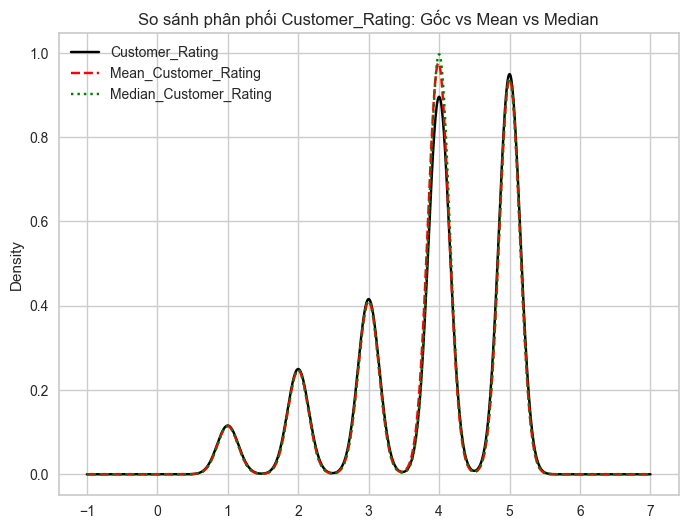

In [433]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [8,6]
fig = plt.figure()
ax = fig.add_subplot(111)
# Vẽ biểu đồ KDE 
df['Customer_Rating'].plot(kind='kde', ax=ax, color='black')
df['Mean_Customer_Rating'].plot(kind='kde', ax=ax, color='red', linestyle='--')
df['Median_Customer_Rating'].plot(kind='kde', ax=ax, color='green', linestyle=':')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')
plt.title('So sánh phân phối Customer_Rating: Gốc vs Mean vs Median')
plt.show()

In [435]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(rating_median)

In [437]:
df["Customer_Rating"].isna().sum()

np.int64(0)

In [439]:
df.drop(columns=["Mean_Customer_Rating", "Median_Customer_Rating"], axis = 1, inplace = True)

In [441]:
# Đếm số lượng giá trị trùng lặp của bộ giá trị
df.duplicated().sum()

np.int64(1935)

In [443]:
df.drop_duplicates(keep = "first", inplace = True)

In [445]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22114 entries, 0 to 23017
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  22114 non-null  object 
 1   Customer_ID               22114 non-null  object 
 2   Date                      22114 non-null  object 
 3   Age                       22114 non-null  float64
 4   Gender                    22114 non-null  object 
 5   City                      22114 non-null  object 
 6   Product_Category          22114 non-null  object 
 7   Unit_Price                22114 non-null  float64
 8   Quantity                  22114 non-null  int64  
 9   Discount_Amount           22114 non-null  float64
 10  Total_Amount              22114 non-null  float64
 11  Payment_Method            22114 non-null  object 
 12  Device_Type               22114 non-null  object 
 13  Session_Duration_Minutes  22114 non-null  int64  
 14  Pages_Viewe

# Lưu dữ liệu đã được làm sạch và chuyển đổi

In [448]:
#Lưu dữ liệu đã được làm sạch và chuyển đổi
df.to_csv('E-Commerce Customer Behavior Analysis_full_cleaned.csv', index=False)

# Phân tích khám phá dữ liệu EDA

In [143]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27.0,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8.0,5.0
1,ORD_004885,CUST_04885,2023-01-01,42.0,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3.0,3.0
2,ORD_004507,CUST_04507,2023-01-01,43.0,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5.0,2.0
3,ORD_000645,CUST_00645,2023-01-01,32.0,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1.0,4.0
4,ORD_000690,CUST_00690,2023-01-01,40.0,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7.0,4.0


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22114 entries, 0 to 23017
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  22114 non-null  object 
 1   Customer_ID               22114 non-null  object 
 2   Date                      22114 non-null  object 
 3   Age                       22114 non-null  float64
 4   Gender                    22114 non-null  object 
 5   City                      22114 non-null  object 
 6   Product_Category          22114 non-null  object 
 7   Unit_Price                22114 non-null  float64
 8   Quantity                  22114 non-null  int64  
 9   Discount_Amount           22114 non-null  float64
 10  Total_Amount              22114 non-null  float64
 11  Payment_Method            22114 non-null  object 
 12  Device_Type               22114 non-null  object 
 13  Session_Duration_Minutes  22114 non-null  int64  
 14  Pages_Viewe

# Phân tích hành vi mua sắm của khách hàng

In [148]:
df["Total_Amount"].value_counts().sort_index()

Total_Amount
6.21        1
6.30        1
7.00        1
7.59        1
7.87        1
           ..
28638.86    1
28640.75    1
29045.35    1
32823.53    1
37852.05    1
Name: count, Length: 20098, dtype: int64

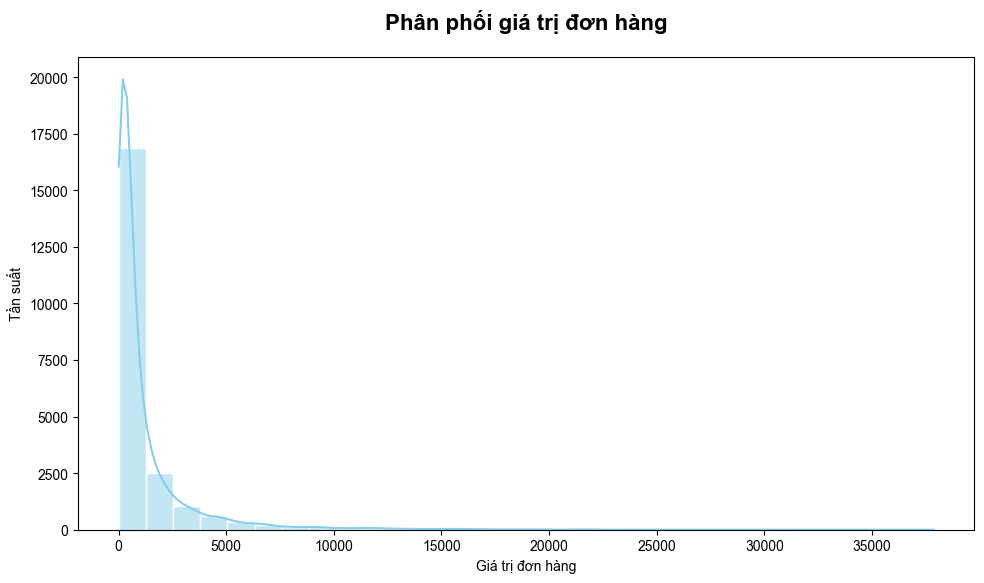

In [150]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

sns.set_theme(style="whitegrid")

# Vẽ biểu đồ histplot
sns.histplot(data=df, x='Total_Amount', kde=True, ax=axes, color='skyblue', bins=30)

# Tùy chỉnh tiêu đề và nhãn
axes.set_title('Phân phối giá trị đơn hàng', fontsize=16, fontweight='bold', pad=20)
axes.set_xlabel('Giá trị đơn hàng')
axes.set_ylabel('Tần suất')

# Hiển thị biểu đồ
sns.set(style="whitegrid")
plt.tight_layout()
plt.show()


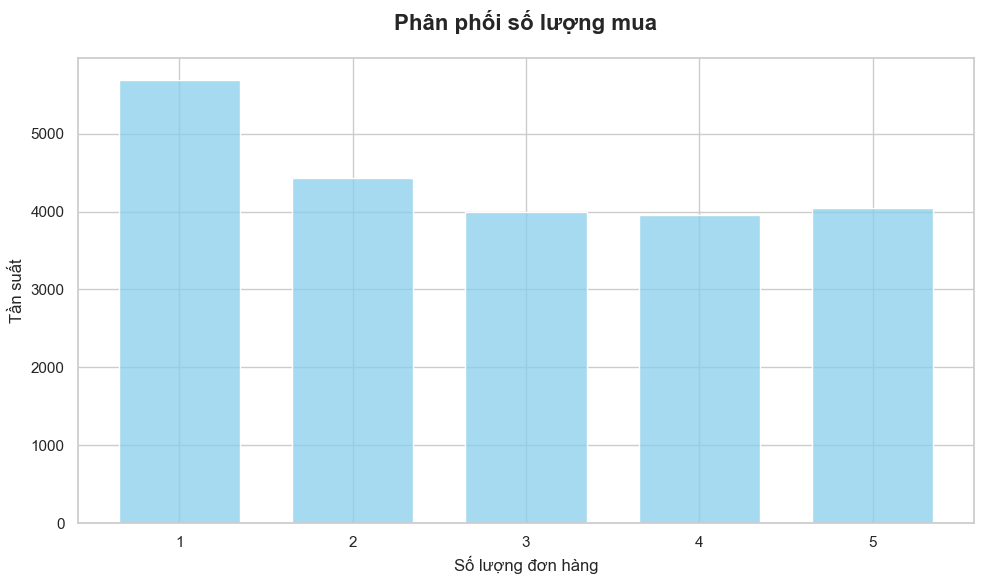

In [152]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Vẽ biểu đồ histplot
sns.histplot(
    data=df
    , x='Quantity'
    , ax=axes
    , color='skyblue'
    , discrete=True
    , shrink= 0.7
    , bins=5)

# Tùy chỉnh tiêu đề và nhãn
axes.set_title('Phân phối số lượng mua', fontsize=16, fontweight='bold', pad=20)
axes.set_xlabel('Số lượng đơn hàng')
axes.set_ylabel('Tần suất')

# Hiển thị biểu đồ
sns.set(style="whitegrid")
plt.tight_layout()
plt.show()


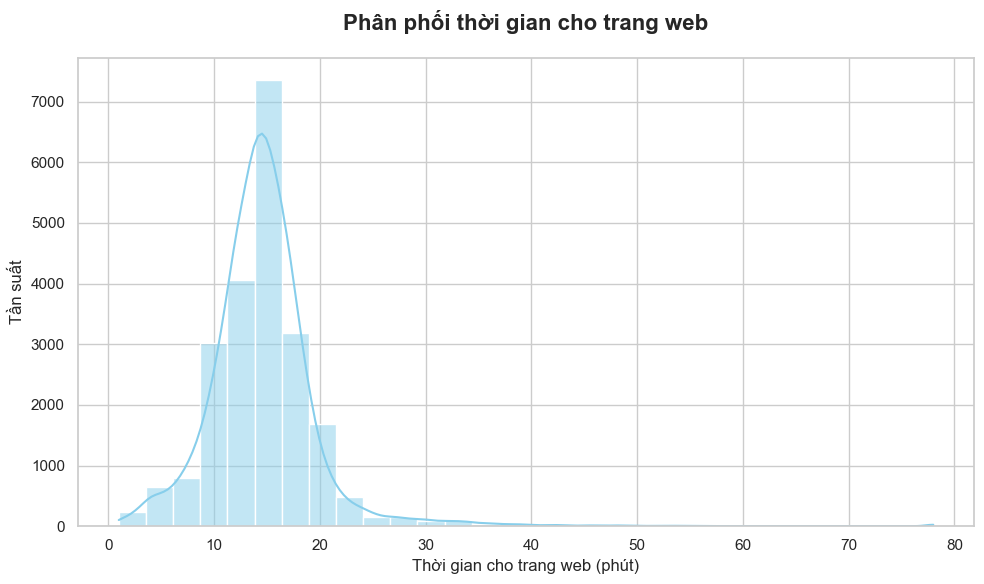

In [154]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Vẽ biểu đồ histplot
sns.histplot(data=df, x='Session_Duration_Minutes', kde=True, ax=axes, color='skyblue', bins=30)

# Tùy chỉnh tiêu đề và nhãn
axes.set_title('Phân phối thời gian cho trang web', fontsize=16, fontweight='bold', pad=20)
axes.set_xlabel('Thời gian cho trang web (phút)')
axes.set_ylabel('Tần suất')

# Hiển thị biểu đồ
sns.set(style="whitegrid")
plt.tight_layout()
plt.show()


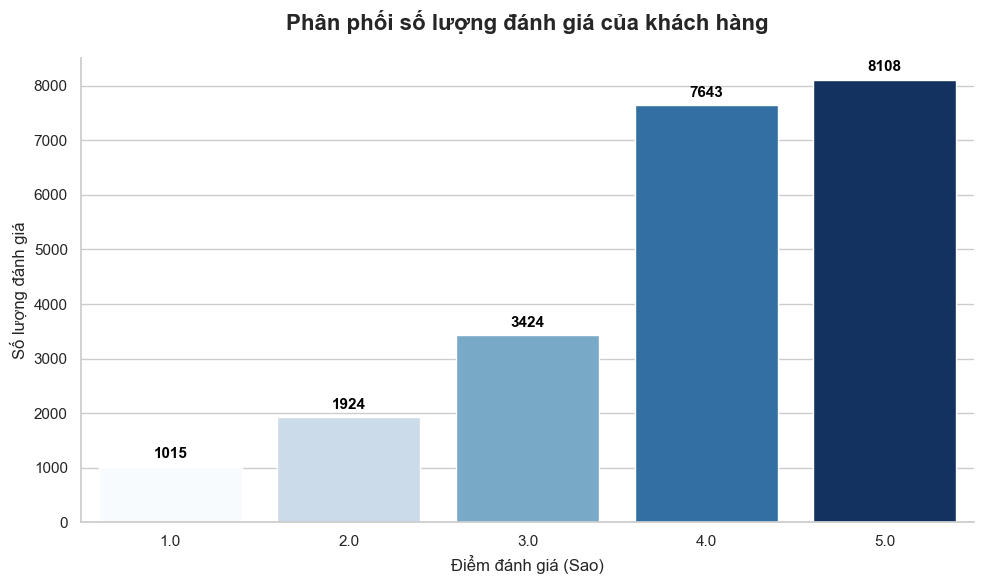

In [156]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df, 
    x="Customer_Rating", 
    ax=ax, 
    palette="Blues",   # Dải màu xanh từ nhạt đến đậm theo mức độ đánh giá
    hue="Customer_Rating", # Tránh cảnh báo của Seaborn mới
    legend=False
)

ax.set_title('Phân phối số lượng đánh giá của khách hàng', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Điểm đánh giá (Sao)', fontsize=12)
ax.set_ylabel('Số lượng đánh giá', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='black')

sns.despine()

plt.tight_layout()
plt.show()


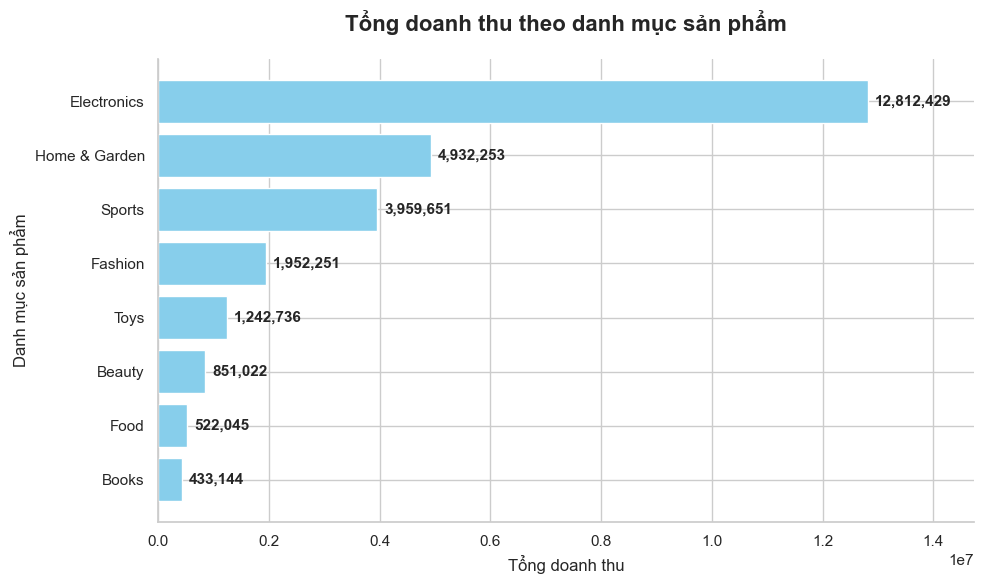

In [158]:
category_revenue = df.groupby("Product_Category")["Total_Amount"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(category_revenue.index, category_revenue.values, color='skyblue', edgecolor='white')

ax.set_title('Tổng doanh thu theo danh mục sản phẩm', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tổng doanh thu', fontsize=12)
ax.set_ylabel('Danh mục sản phẩm', fontsize=12)

ax.bar_label(bars, padding=5, fmt='{:,.0f}', fontsize=11, fontweight='bold')

ax.set_xlim(right=category_revenue.max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

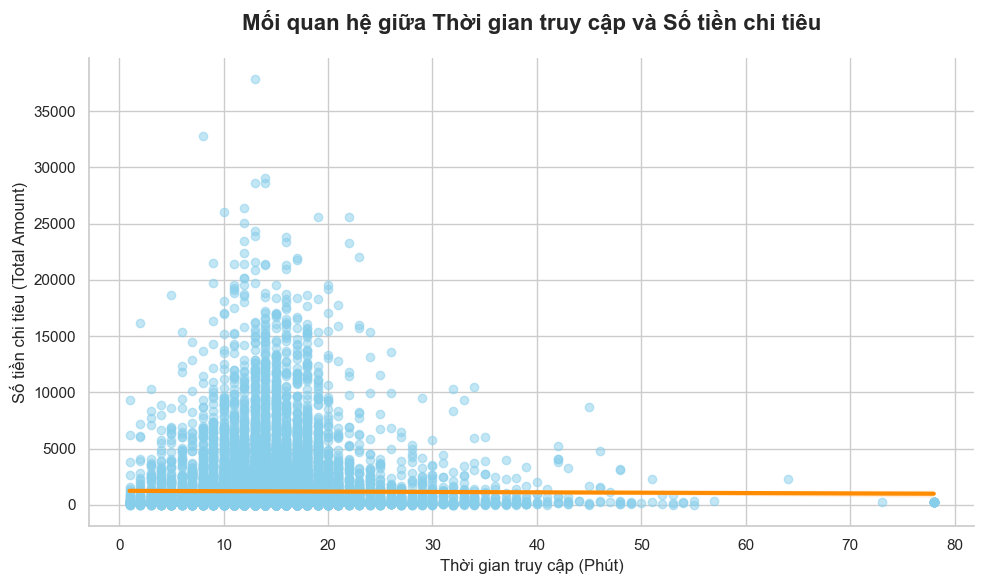

In [160]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df, 
    x='Session_Duration_Minutes', 
    y='Total_Amount', 
    scatter_kws={'alpha':0.5, 'color': 'skyblue'}, 
    line_kws={'color': 'darkorange', 'lw': 3}      
)

plt.title('Mối quan hệ giữa Thời gian truy cập và Số tiền chi tiêu', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Thời gian truy cập (Phút)', fontsize=12)
plt.ylabel('Số tiền chi tiêu (Total Amount)', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

# Phân tích nhân khẩu học khách hàng

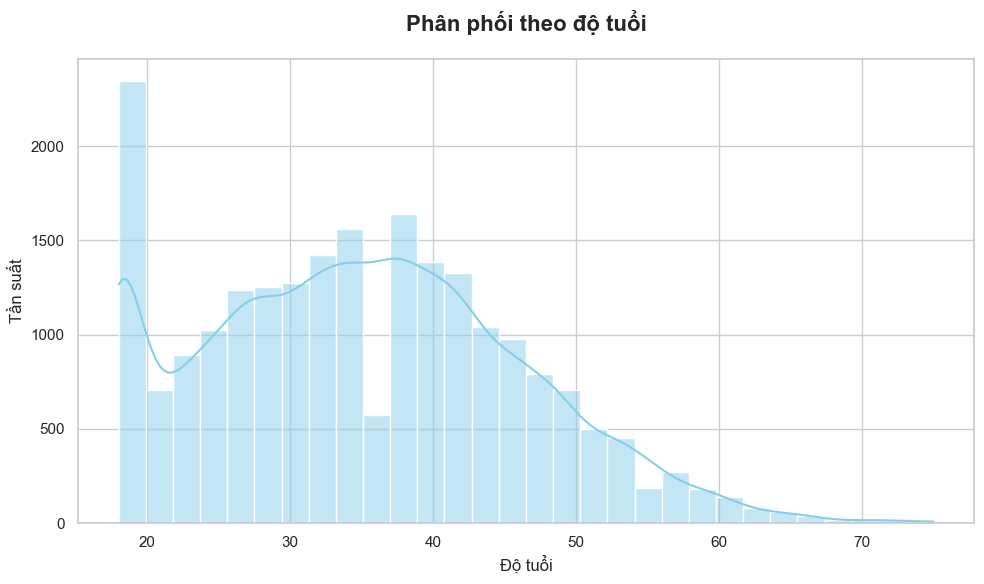

In [163]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Vẽ biểu đồ histplot
sns.histplot(data=df, x='Age', kde=True, ax=axes, color='skyblue', bins=30)

# Tùy chỉnh tiêu đề và nhãn
axes.set_title('Phân phối theo độ tuổi', fontsize=16, fontweight='bold', pad=20)
axes.set_xlabel('Độ tuổi')
axes.set_ylabel('Tần suất')

# Hiển thị biểu đồ
sns.set(style="whitegrid")
plt.tight_layout()
plt.show()


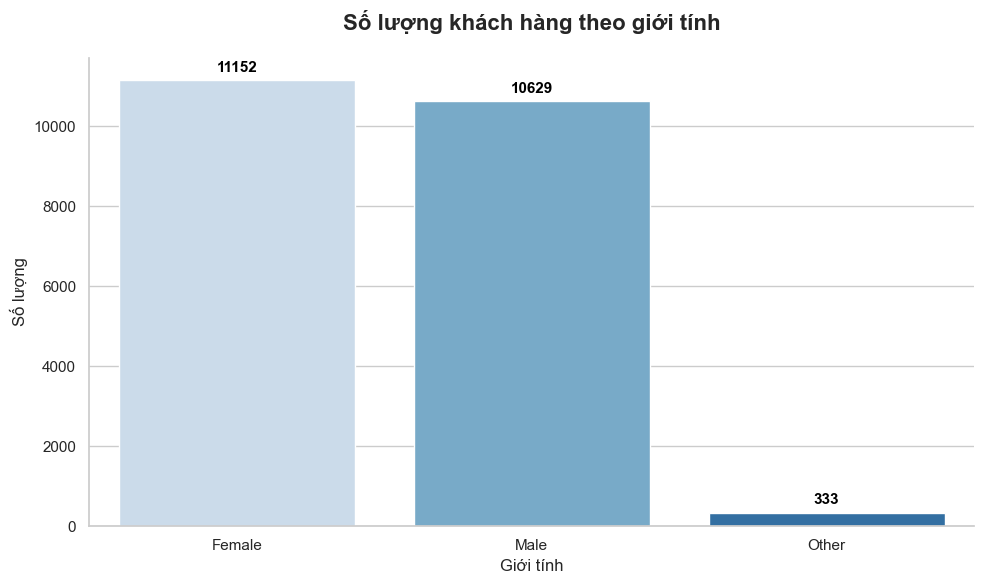

In [165]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df, 
    x="Gender", 
    ax=ax, 
    palette="Blues",   # Dải màu xanh từ nhạt đến đậm theo mức độ đánh giá
    hue="Gender", # Tránh cảnh báo của Seaborn mới
    legend=False
)

ax.set_title('Số lượng khách hàng theo giới tính', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Giới tính', fontsize=12)
ax.set_ylabel('Số lượng', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='black')

sns.despine()

plt.tight_layout()
plt.show()


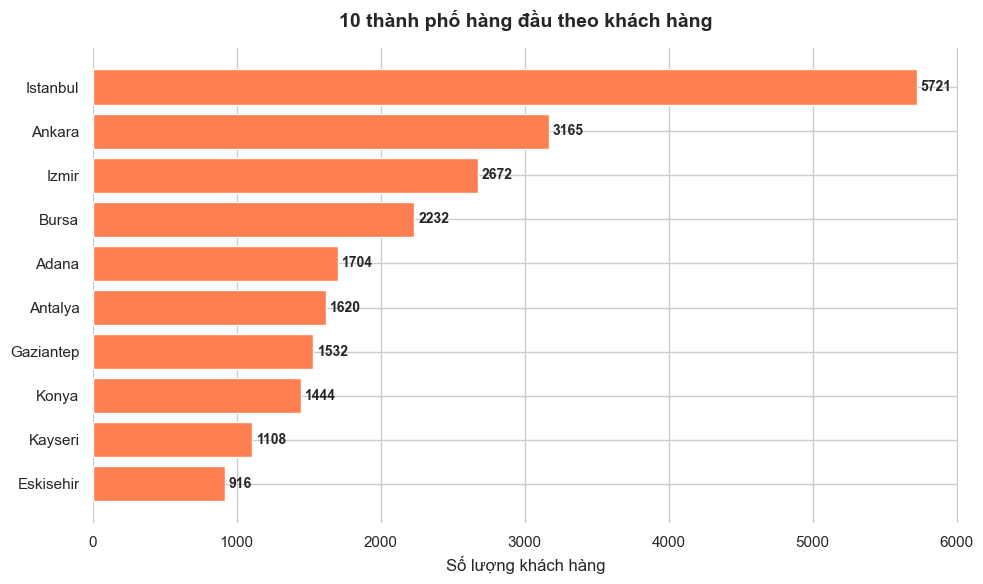

In [167]:
fig, ax = plt.subplots(figsize=(10, 6))

city_counts = df['City'].value_counts().head(10)

bars = plt.barh(city_counts.index, city_counts.values, color='coral', edgecolor='white')

plt.gca().invert_yaxis()

plt.title('10 thành phố hàng đầu theo khách hàng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng khách hàng', fontsize=12)

plt.bar_label(bars, padding=3, fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Tương quan Heatmap

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22114 entries, 0 to 23017
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  22114 non-null  object 
 1   Customer_ID               22114 non-null  object 
 2   Date                      22114 non-null  object 
 3   Age                       22114 non-null  float64
 4   Gender                    22114 non-null  object 
 5   City                      22114 non-null  object 
 6   Product_Category          22114 non-null  object 
 7   Unit_Price                22114 non-null  float64
 8   Quantity                  22114 non-null  int64  
 9   Discount_Amount           22114 non-null  float64
 10  Total_Amount              22114 non-null  float64
 11  Payment_Method            22114 non-null  object 
 12  Device_Type               22114 non-null  object 
 13  Session_Duration_Minutes  22114 non-null  int64  
 14  Pages_Viewe

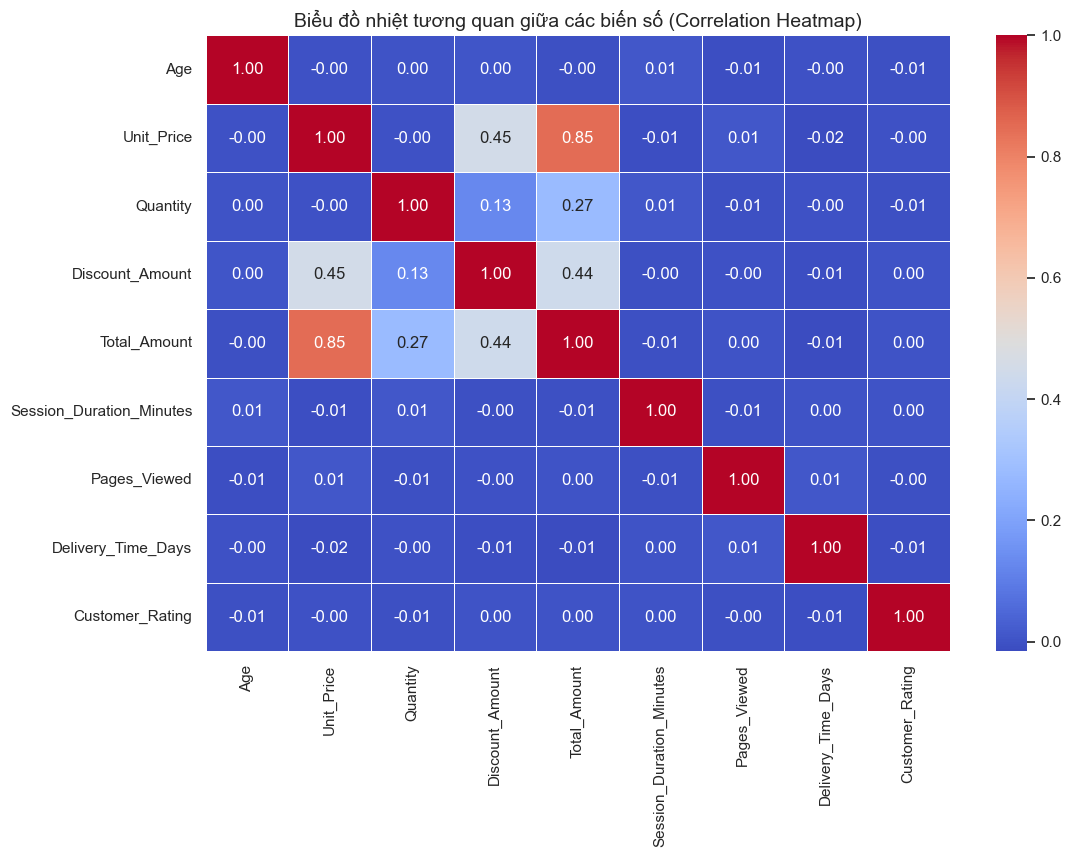

In [172]:
numerical_cols = ['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 
                  'Total_Amount', 'Session_Duration_Minutes', 
                  'Pages_Viewed', 'Delivery_Time_Days', 'Customer_Rating']
df_corr = df[numerical_cols]
correlation_matrix = df_corr.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Biểu đồ nhiệt tương quan giữa các biến số (Correlation Heatmap)', fontsize=14)
plt.show()

In [174]:
df["City"].value_counts()

City
Istanbul     5721
Ankara       3165
Izmir        2672
Bursa        2232
Adana        1704
Antalya      1620
Gaziantep    1532
Konya        1444
Kayseri      1108
Eskisehir     916
Name: count, dtype: int64

# Lựa chọn đặc trưng

In [272]:
df_temp = pd.read_csv("E-Commerce Customer Behavior Analysis_full_cleaned.csv")

In [274]:
# Xác định các cột cần loại bỏ
cols_to_drop = ['Order_ID', 'Customer_ID', 'Date', 'Delivery_Time_Days', 'Unit_Price']
df_temp.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [276]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       22114 non-null  float64
 1   Gender                    22114 non-null  object 
 2   City                      22114 non-null  object 
 3   Product_Category          22114 non-null  object 
 4   Quantity                  22114 non-null  int64  
 5   Discount_Amount           22114 non-null  float64
 6   Total_Amount              22114 non-null  float64
 7   Payment_Method            22114 non-null  object 
 8   Device_Type               22114 non-null  object 
 9   Session_Duration_Minutes  22114 non-null  int64  
 10  Pages_Viewed              22114 non-null  int64  
 11  Is_Returning_Customer     22114 non-null  bool   
 12  Customer_Rating           22114 non-null  float64
dtypes: bool(1), float64(4), int64(3), object(5)
memory usage: 2.0

# Xử lý ngoại lai (Outlier Handling)

In [279]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       22114 non-null  float64
 1   Gender                    22114 non-null  object 
 2   City                      22114 non-null  object 
 3   Product_Category          22114 non-null  object 
 4   Quantity                  22114 non-null  int64  
 5   Discount_Amount           22114 non-null  float64
 6   Total_Amount              22114 non-null  float64
 7   Payment_Method            22114 non-null  object 
 8   Device_Type               22114 non-null  object 
 9   Session_Duration_Minutes  22114 non-null  int64  
 10  Pages_Viewed              22114 non-null  int64  
 11  Is_Returning_Customer     22114 non-null  bool   
 12  Customer_Rating           22114 non-null  float64
dtypes: bool(1), float64(4), int64(3), object(5)
memory usage: 2.0

In [281]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       22114 non-null  float64
 1   Gender                    22114 non-null  object 
 2   City                      22114 non-null  object 
 3   Product_Category          22114 non-null  object 
 4   Quantity                  22114 non-null  int64  
 5   Discount_Amount           22114 non-null  float64
 6   Total_Amount              22114 non-null  float64
 7   Payment_Method            22114 non-null  object 
 8   Device_Type               22114 non-null  object 
 9   Session_Duration_Minutes  22114 non-null  int64  
 10  Pages_Viewed              22114 non-null  int64  
 11  Is_Returning_Customer     22114 non-null  bool   
 12  Customer_Rating           22114 non-null  float64
dtypes: bool(1), float64(4), int64(3), object(5)
memory usage: 2.0

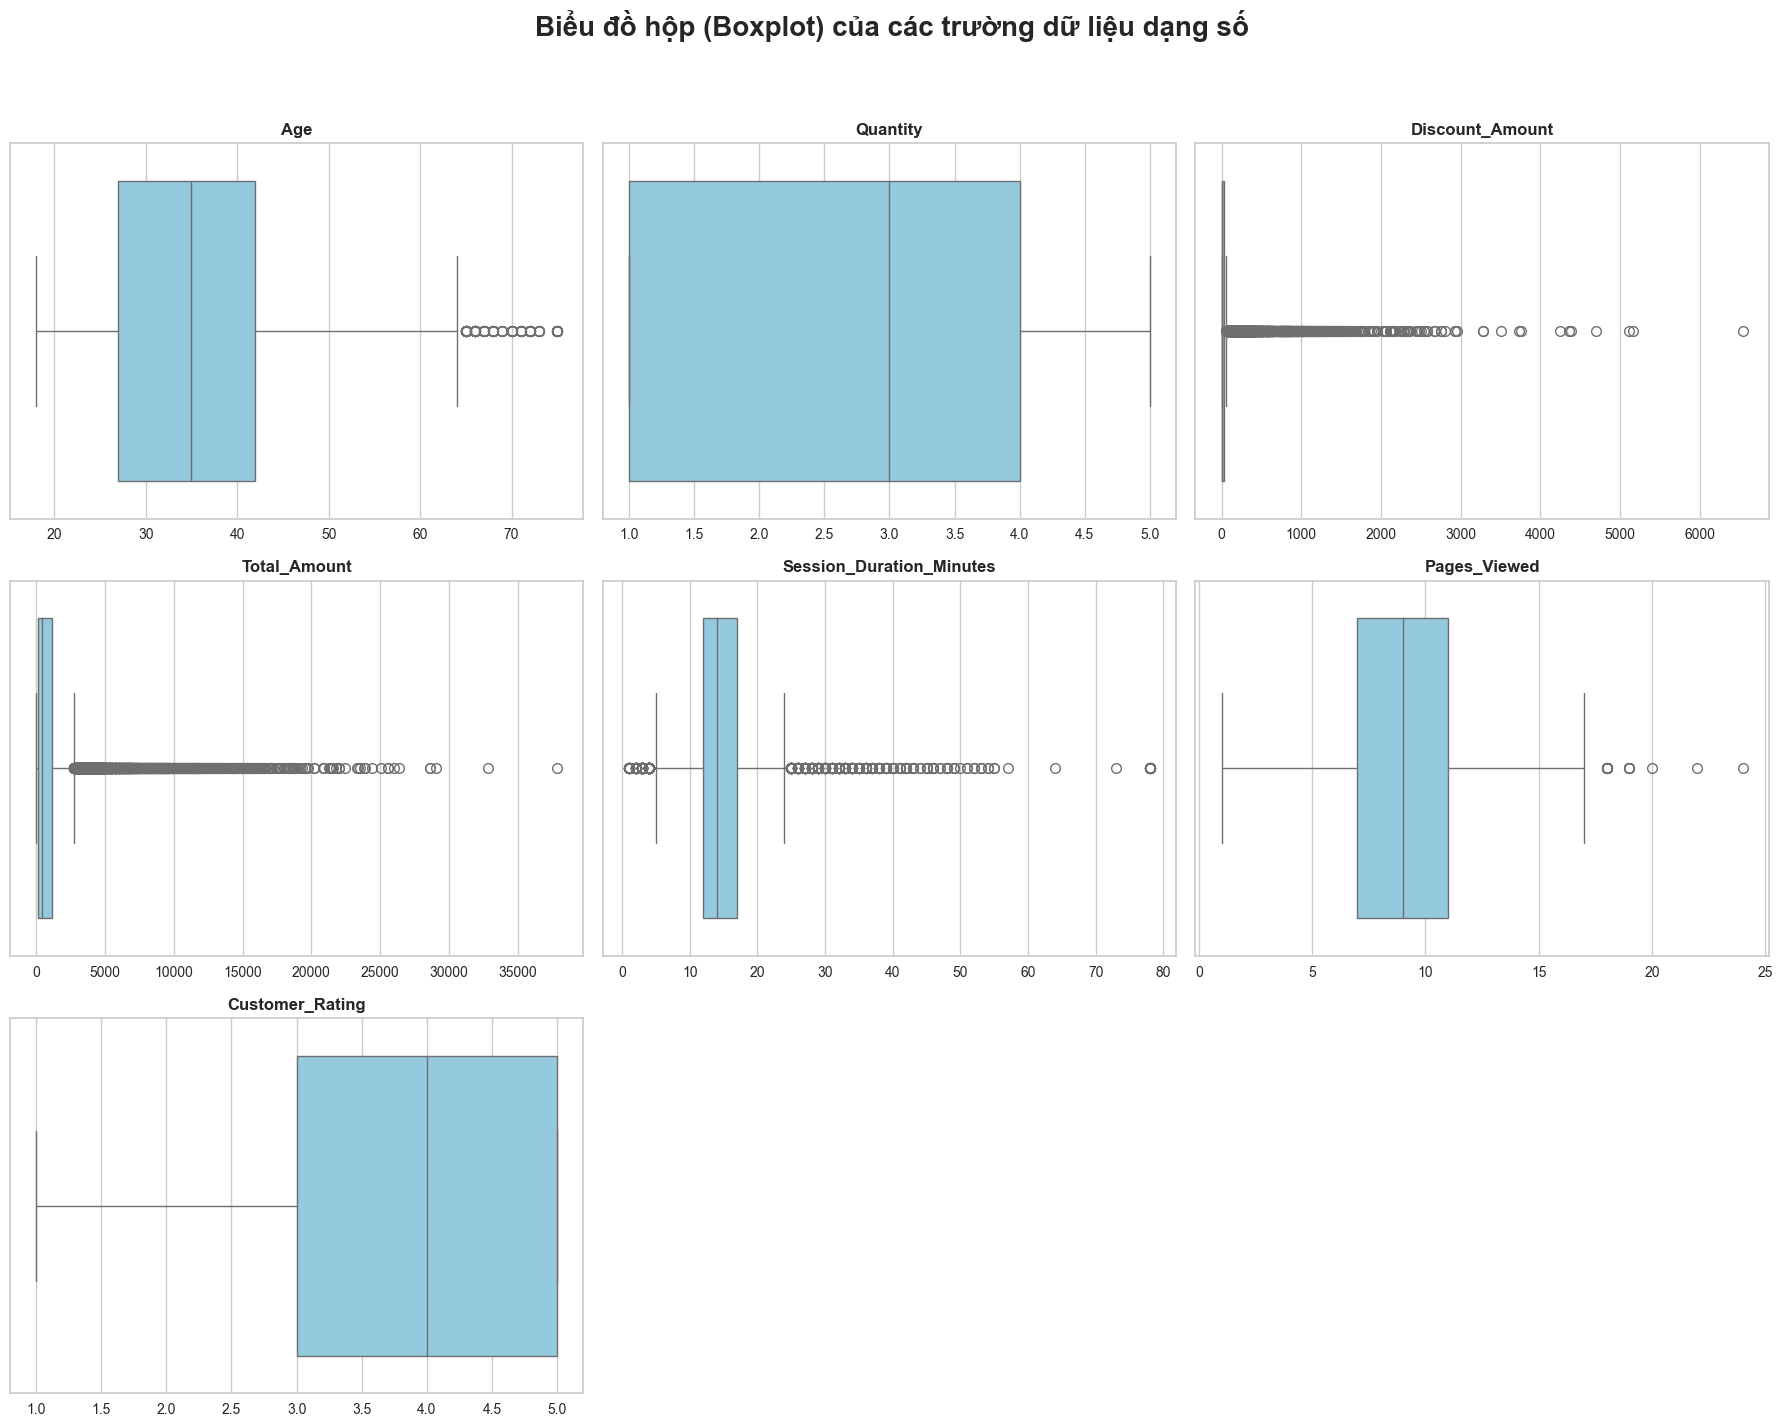

In [283]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Quantity', 'Discount_Amount', 'Total_Amount', 
                  'Session_Duration_Minutes', 'Pages_Viewed', 'Customer_Rating']

# Khởi tạo lưới 3x3 (9 ô)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Biểu đồ hộp (Boxplot) của các trường dữ liệu dạng số', fontsize=20, fontweight='bold')

# Làm phẳng mảng axes để dễ truy cập bằng 1 chỉ số duy nhất
axes_flat = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_temp, x=col, ax=axes_flat[i], color='skyblue')
    axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')

# Vòng lặp này sẽ ẩn các ô còn thừa (ô thứ 8 và 9)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


<Axes: xlabel='Total_Amount_Log', ylabel='Count'>

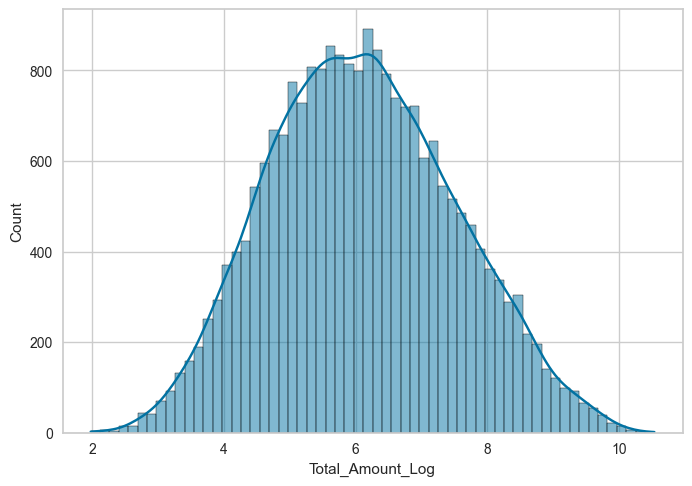

In [284]:
# Sử dụng log1p (log(x+1)) để xử lý vấn đề lệch phải và nén outlier
# log1p giúp tránh lỗi nếu Total_Amount có giá trị 0
df_temp['Total_Amount_Log'] = np.log1p(df_temp['Total_Amount'])
sns.histplot(df_temp['Total_Amount_Log'], kde=True)

In [285]:
cols_red_alert = ['Discount_Amount']
cols_mild = ['Session_Duration_Minutes', 'Pages_Viewed']

for col in cols_red_alert:
    limit = df_temp[col].quantile(0.95)
    df_temp[col] = np.where(df_temp[col] > limit, limit, df_temp[col])

for col in cols_mild:
    limit = df_temp[col].quantile(0.99)
    df_temp[col] = np.where(df_temp[col] > limit, limit, df_temp[col])

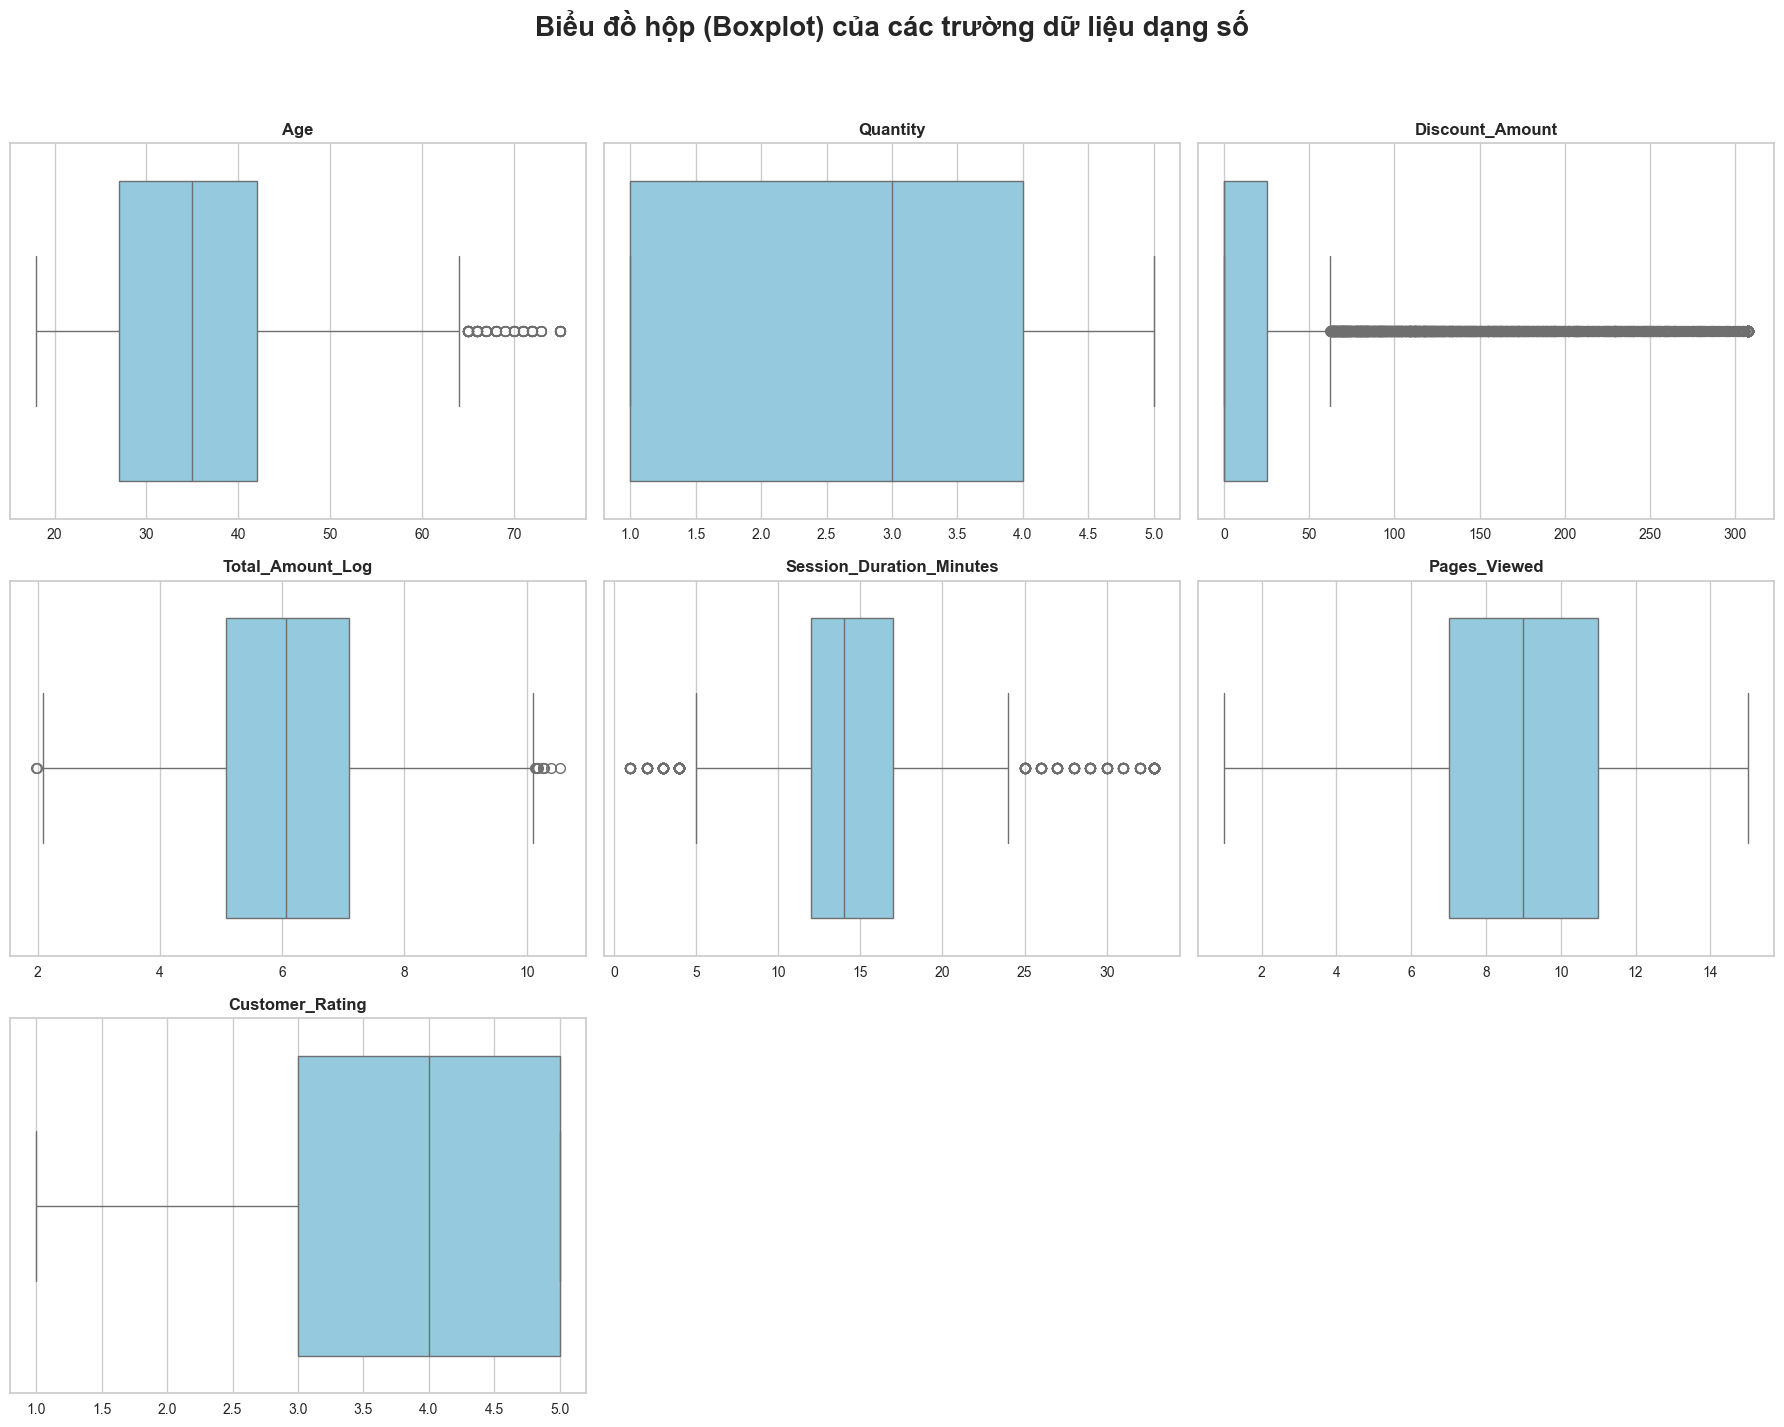

In [286]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Quantity', 'Discount_Amount', 'Total_Amount_Log', 
                  'Session_Duration_Minutes', 'Pages_Viewed', 'Customer_Rating']

# Khởi tạo lưới 3x3 (9 ô)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Biểu đồ hộp (Boxplot) của các trường dữ liệu dạng số', fontsize=20, fontweight='bold')

# Làm phẳng mảng axes để dễ truy cập bằng 1 chỉ số duy nhất
axes_flat = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_temp, x=col, ax=axes_flat[i], color='skyblue')
    axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')

# Vòng lặp này sẽ ẩn các ô còn thừa (ô thứ 8 và 9)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [288]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       22114 non-null  float64
 1   Gender                    22114 non-null  object 
 2   City                      22114 non-null  object 
 3   Product_Category          22114 non-null  object 
 4   Quantity                  22114 non-null  int64  
 5   Discount_Amount           22114 non-null  float64
 6   Total_Amount              22114 non-null  float64
 7   Payment_Method            22114 non-null  object 
 8   Device_Type               22114 non-null  object 
 9   Session_Duration_Minutes  22114 non-null  float64
 10  Pages_Viewed              22114 non-null  float64
 11  Is_Returning_Customer     22114 non-null  bool   
 12  Customer_Rating           22114 non-null  float64
 13  Total_Amount_Log          22114 non-null  float64
dtypes: boo

In [291]:
df_temp.to_csv('sales_df_original.csv', index=False)

In [292]:
df_temp = pd.read_csv("sales_df_original.csv")

In [294]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       22114 non-null  float64
 1   Gender                    22114 non-null  object 
 2   City                      22114 non-null  object 
 3   Product_Category          22114 non-null  object 
 4   Quantity                  22114 non-null  int64  
 5   Discount_Amount           22114 non-null  float64
 6   Total_Amount              22114 non-null  float64
 7   Payment_Method            22114 non-null  object 
 8   Device_Type               22114 non-null  object 
 9   Session_Duration_Minutes  22114 non-null  float64
 10  Pages_Viewed              22114 non-null  float64
 11  Is_Returning_Customer     22114 non-null  bool   
 12  Customer_Rating           22114 non-null  float64
 13  Total_Amount_Log          22114 non-null  float64
dtypes: boo

# Mã hóa dữ liệu

# Chuẩn hóa dữ liệu trong cột Age 

In [298]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

unique_ages = df_temp['Age'].unique()
df_unique_age = pd.DataFrame(unique_ages, columns=['Age'])

scaler = MinMaxScaler()
df_unique_age['Age_Scaled'] = scaler.fit_transform(df_unique_age[['Age']])
df_temp = df_temp.merge(df_unique_age, on='Age', how='left')

In [302]:
df_temp[["Age" ,"Age_Scaled"]]

,Age,Age_Scaled
0,27.0,0.157895
1,42.0,0.421053
2,43.0,0.438596
3,32.0,0.245614
4,40.0,0.385965
...,...,...
22109,35.0,0.298246
22110,35.0,0.298246
22111,35.0,0.298246
22112,35.0,0.298246


# Chuẩn hóa dữ liệu Quantity

In [306]:
df_temp["Quantity"].value_counts()

Quantity
1    5690
2    4431
5    4043
3    3997
4    3953
Name: count, dtype: int64

In [308]:
# Chuẩn hóa cột Quantity (Min-Max Scaling)
scaler = MinMaxScaler()
df_temp['Quantity_Scaled'] = scaler.fit_transform(df_temp[['Quantity']])

In [310]:
df_temp.head()

,Age,Gender,City,Product_Category,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Customer_Rating,Total_Amount_Log,Age_Scaled,Quantity_Scaled
0,27.0,Female,Bursa,Toys,1,0.00,54.28,Debit Card,Mobile,4.0,14.0,True,5.0,4.012411,0.157895,0.0
1,42.0,Male,Konya,Toys,1,0.00,244.90,Credit Card,Mobile,11.0,3.0,True,3.0,5.504925,0.421053,0.0
2,43.0,Female,Ankara,Food,5,0.00,240.75,Credit Card,Mobile,7.0,8.0,True,2.0,5.487904,0.438596,1.0
3,32.0,Male,Istanbul,Electronics,1,229.28,574.78,Credit Card,Mobile,8.0,10.0,False,4.0,6.355726,0.245614,0.0
4,40.0,Female,Istanbul,Sports,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,10.0,True,4.0,8.237228,0.385965,1.0


In [312]:
df_temp["Quantity_Scaled"].value_counts()

Quantity_Scaled
0.00    5690
0.25    4431
1.00    4043
0.50    3997
0.75    3953
Name: count, dtype: int64

# Chuẩn hóa dữ liệu Discount_Amount

In [315]:
df_temp["Discount_Amount"].value_counts()

Discount_Amount
0.000      14108
307.531     1106
3.840          7
7.880          6
8.390          6
           ...  
13.120         1
118.430        1
26.070         1
108.460        1
217.010        1
Name: count, Length: 5368, dtype: int64

In [317]:
# Chuẩn hóa cột Discount_Amount (Min-Max Scaling)
scaler = MinMaxScaler()
df_temp['Discount_Amount_Scaled'] = scaler.fit_transform(df_temp[['Discount_Amount']])

In [319]:
df_temp.head()

,Age,Gender,City,Product_Category,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Customer_Rating,Total_Amount_Log,Age_Scaled,Quantity_Scaled,Discount_Amount_Scaled
0,27.0,Female,Bursa,Toys,1,0.00,54.28,Debit Card,Mobile,4.0,14.0,True,5.0,4.012411,0.157895,0.0,0.000000
1,42.0,Male,Konya,Toys,1,0.00,244.90,Credit Card,Mobile,11.0,3.0,True,3.0,5.504925,0.421053,0.0,0.000000
2,43.0,Female,Ankara,Food,5,0.00,240.75,Credit Card,Mobile,7.0,8.0,True,2.0,5.487904,0.438596,1.0,0.000000
3,32.0,Male,Istanbul,Electronics,1,229.28,574.78,Credit Card,Mobile,8.0,10.0,False,4.0,6.355726,0.245614,0.0,0.745551
4,40.0,Female,Istanbul,Sports,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,10.0,True,4.0,8.237228,0.385965,1.0,0.000000


# Chuẩn hóa dữ liệu Total_Amount 

In [322]:
df_temp["Total_Amount_Log"].value_counts()

Total_Amount_Log
4.012411    32
5.487904    17
5.504925    16
5.158940     5
4.426522     4
            ..
5.716106     1
6.475926     1
7.583039     1
6.341153     1
8.254505     1
Name: count, Length: 20098, dtype: int64

In [324]:
# Chuẩn hóa cột Total_Amount (Min-Max Scaling)
scaler = MinMaxScaler()
df_temp['Total_Amount_Scaled'] = scaler.fit_transform(df_temp[['Total_Amount_Log']])

In [326]:
df_temp.head()

,Age,Gender,City,Product_Category,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Customer_Rating,Total_Amount_Log,Age_Scaled,Quantity_Scaled,Discount_Amount_Scaled,Total_Amount_Scaled
0,27.0,Female,Bursa,Toys,1,0.00,54.28,Debit Card,Mobile,4.0,14.0,True,5.0,4.012411,0.157895,0.0,0.000000,0.237794
1,42.0,Male,Konya,Toys,1,0.00,244.90,Credit Card,Mobile,11.0,3.0,True,3.0,5.504925,0.421053,0.0,0.000000,0.412031
2,43.0,Female,Ankara,Food,5,0.00,240.75,Credit Card,Mobile,7.0,8.0,True,2.0,5.487904,0.438596,1.0,0.000000,0.410044
3,32.0,Male,Istanbul,Electronics,1,229.28,574.78,Credit Card,Mobile,8.0,10.0,False,4.0,6.355726,0.245614,0.0,0.745551,0.511354
4,40.0,Female,Istanbul,Sports,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,10.0,True,4.0,8.237228,0.385965,1.0,0.000000,0.731002


# Chuẩn hóa dữ liệu Session_Duration_Minutes

In [329]:
df_temp["Session_Duration_Minutes"].value_counts()

Session_Duration_Minutes
14.00    2576
15.00    2551
16.00    2227
13.00    2198
12.00    1868
17.00    1851
11.00    1374
18.00    1333
10.00     982
19.00     856
9.00      663
20.00     517
8.00      465
7.00      334
21.00     319
6.00      243
32.87     222
22.00     211
5.00      208
4.00      201
23.00     148
3.00      122
24.00     119
25.00      84
2.00       67
27.00      62
26.00      61
28.00      52
30.00      45
29.00      45
1.00       43
32.00      34
31.00      33
Name: count, dtype: int64

In [331]:
# Chuẩn hóa cột Session_Duration_Minutes (Min-Max Scaling)
scaler = MinMaxScaler()
df_temp['Session_Duration_Minutes_Scaled'] = scaler.fit_transform(df_temp[['Session_Duration_Minutes']])

In [333]:
df_temp.head()

,Age,Gender,City,Product_Category,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Customer_Rating,Total_Amount_Log,Age_Scaled,Quantity_Scaled,Discount_Amount_Scaled,Total_Amount_Scaled,Session_Duration_Minutes_Scaled
0,27.0,Female,Bursa,Toys,1,0.00,54.28,Debit Card,Mobile,4.0,14.0,True,5.0,4.012411,0.157895,0.0,0.000000,0.237794,0.094132
1,42.0,Male,Konya,Toys,1,0.00,244.90,Credit Card,Mobile,11.0,3.0,True,3.0,5.504925,0.421053,0.0,0.000000,0.412031,0.313775
2,43.0,Female,Ankara,Food,5,0.00,240.75,Credit Card,Mobile,7.0,8.0,True,2.0,5.487904,0.438596,1.0,0.000000,0.410044,0.188265
3,32.0,Male,Istanbul,Electronics,1,229.28,574.78,Credit Card,Mobile,8.0,10.0,False,4.0,6.355726,0.245614,0.0,0.745551,0.511354,0.219642
4,40.0,Female,Istanbul,Sports,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,10.0,True,4.0,8.237228,0.385965,1.0,0.000000,0.731002,0.627549


In [335]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              22114 non-null  float64
 1   Gender                           22114 non-null  object 
 2   City                             22114 non-null  object 
 3   Product_Category                 22114 non-null  object 
 4   Quantity                         22114 non-null  int64  
 5   Discount_Amount                  22114 non-null  float64
 6   Total_Amount                     22114 non-null  float64
 7   Payment_Method                   22114 non-null  object 
 8   Device_Type                      22114 non-null  object 
 9   Session_Duration_Minutes         22114 non-null  float64
 10  Pages_Viewed                     22114 non-null  float64
 11  Is_Returning_Customer            22114 non-null  bool   
 12  Customer_Rating   

# Chuẩn hóa các cột số còn lại

In [338]:
# Chuẩn hóa các cột số còn lại (Min-Max Scaling)
scaler = MinMaxScaler()

df_temp['Pages_Viewed_Scaled'] = scaler.fit_transform(df_temp[['Pages_Viewed']])
df_temp['Customer_Rating_Scaled'] = scaler.fit_transform(df_temp[['Customer_Rating']])

In [340]:
df_temp.head()

,Age,Gender,City,Product_Category,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,...,Is_Returning_Customer,Customer_Rating,Total_Amount_Log,Age_Scaled,Quantity_Scaled,Discount_Amount_Scaled,Total_Amount_Scaled,Session_Duration_Minutes_Scaled,Pages_Viewed_Scaled,Customer_Rating_Scaled
0,27.0,Female,Bursa,Toys,1,0.00,54.28,Debit Card,Mobile,4.0,...,True,5.0,4.012411,0.157895,0.0,0.000000,0.237794,0.094132,0.928571,1.00
1,42.0,Male,Konya,Toys,1,0.00,244.90,Credit Card,Mobile,11.0,...,True,3.0,5.504925,0.421053,0.0,0.000000,0.412031,0.313775,0.142857,0.50
2,43.0,Female,Ankara,Food,5,0.00,240.75,Credit Card,Mobile,7.0,...,True,2.0,5.487904,0.438596,1.0,0.000000,0.410044,0.188265,0.500000,0.25
3,32.0,Male,Istanbul,Electronics,1,229.28,574.78,Credit Card,Mobile,8.0,...,False,4.0,6.355726,0.245614,0.0,0.745551,0.511354,0.219642,0.642857,0.75
4,40.0,Female,Istanbul,Sports,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,...,True,4.0,8.237228,0.385965,1.0,0.000000,0.731002,0.627549,0.642857,0.75


In [342]:
df_temp["Is_Returning_Customer"].value_counts()

Is_Returning_Customer
True     18091
False     4023
Name: count, dtype: int64

In [344]:
df_temp['Is_Returning_Customer_Scaled'] = df_temp['Is_Returning_Customer'].astype(int)

In [346]:
df_temp[["Is_Returning_Customer", "Is_Returning_Customer_Scaled"]]

,Is_Returning_Customer,Is_Returning_Customer_Scaled
0,True,1
1,True,1
2,True,1
3,False,0
4,True,1
...,...,...
22109,True,1
22110,True,1
22111,True,1
22112,True,1


# Mã hóa dữ liệu (Encoding)

# Sử dụng One-Hot Encoding cho cột Product_Category

In [350]:
df_temp["Product_Category"].value_counts()

Product_Category
Sports           2915
Beauty           2833
Books            2822
Toys             2746
Food             2738
Electronics      2701
Home & Garden    2681
Fashion          2678
Name: count, dtype: int64

In [352]:
# Sử dụng One-Hot Encoding cho cột Product_Category
df_temp = pd.get_dummies(df_temp, columns=['Product_Category'], prefix='Category', dtype=int)

In [354]:
df_temp.head()

,Age,Gender,City,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,...,Customer_Rating_Scaled,Is_Returning_Customer_Scaled,Category_Beauty,Category_Books,Category_Electronics,Category_Fashion,Category_Food,Category_Home & Garden,Category_Sports,Category_Toys
0,27.0,Female,Bursa,1,0.00,54.28,Debit Card,Mobile,4.0,14.0,...,1.00,1,0,0,0,0,0,0,0,1
1,42.0,Male,Konya,1,0.00,244.90,Credit Card,Mobile,11.0,3.0,...,0.50,1,0,0,0,0,0,0,0,1
2,43.0,Female,Ankara,5,0.00,240.75,Credit Card,Mobile,7.0,8.0,...,0.25,1,0,0,0,0,1,0,0,0
3,32.0,Male,Istanbul,1,229.28,574.78,Credit Card,Mobile,8.0,10.0,...,0.75,0,0,0,1,0,0,0,0,0
4,40.0,Female,Istanbul,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,10.0,...,0.75,1,0,0,0,0,0,0,1,0


In [356]:
# Sử dụng One-Hot Encoding cho cột Gender
df_temp = pd.get_dummies(df_temp, columns=['Gender'], prefix='Gender', dtype=int)

In [358]:
df_temp.head()

,Age,City,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,...,Category_Books,Category_Electronics,Category_Fashion,Category_Food,Category_Home & Garden,Category_Sports,Category_Toys,Gender_Female,Gender_Male,Gender_Other
0,27.0,Bursa,1,0.00,54.28,Debit Card,Mobile,4.0,14.0,True,...,0,0,0,0,0,0,1,1,0,0
1,42.0,Konya,1,0.00,244.90,Credit Card,Mobile,11.0,3.0,True,...,0,0,0,0,0,0,1,0,1,0
2,43.0,Ankara,5,0.00,240.75,Credit Card,Mobile,7.0,8.0,True,...,0,0,0,1,0,0,0,1,0,0
3,32.0,Istanbul,1,229.28,574.78,Credit Card,Mobile,8.0,10.0,False,...,0,1,0,0,0,0,0,0,1,0
4,40.0,Istanbul,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,10.0,True,...,0,0,0,0,0,1,0,1,0,0


In [360]:
# Sử dụng One-Hot Encoding cho cột city
df_temp = pd.get_dummies(df_temp, columns=['City'], prefix='City', dtype=int)

In [362]:
df_temp.head()

,Age,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Customer_Rating,...,City_Adana,City_Ankara,City_Antalya,City_Bursa,City_Eskisehir,City_Gaziantep,City_Istanbul,City_Izmir,City_Kayseri,City_Konya
0,27.0,1,0.00,54.28,Debit Card,Mobile,4.0,14.0,True,5.0,...,0,0,0,1,0,0,0,0,0,0
1,42.0,1,0.00,244.90,Credit Card,Mobile,11.0,3.0,True,3.0,...,0,0,0,0,0,0,0,0,0,1
2,43.0,5,0.00,240.75,Credit Card,Mobile,7.0,8.0,True,2.0,...,0,1,0,0,0,0,0,0,0,0
3,32.0,1,229.28,574.78,Credit Card,Mobile,8.0,10.0,False,4.0,...,0,0,0,0,0,0,1,0,0,0
4,40.0,5,0.00,3778.05,Cash on Delivery,Desktop,21.0,10.0,True,4.0,...,0,0,0,0,0,0,1,0,0,0


# Sử dụng One-Hot Encoding cho cột Payment_Method

In [365]:
df_temp["Payment_Method"].value_counts()

Payment_Method
Credit Card         8863
Debit Card          5601
Digital Wallet      4241
Bank Transfer       2273
Cash on Delivery    1136
Name: count, dtype: int64

In [367]:
# Sử dụng One-Hot Encoding cho Payment_Method (5 cột)
# Tạo ra: Pay_Credit Card, Pay_Digital Wallet, v.v.
df_temp = pd.get_dummies(df_temp, columns=['Payment_Method'], prefix='Pay', dtype=int)

In [369]:
df_temp.head()

,Age,Quantity,Discount_Amount,Total_Amount,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Customer_Rating,Total_Amount_Log,...,City_Gaziantep,City_Istanbul,City_Izmir,City_Kayseri,City_Konya,Pay_Bank Transfer,Pay_Cash on Delivery,Pay_Credit Card,Pay_Debit Card,Pay_Digital Wallet
0,27.0,1,0.00,54.28,Mobile,4.0,14.0,True,5.0,4.012411,...,0,0,0,0,0,0,0,0,1,0
1,42.0,1,0.00,244.90,Mobile,11.0,3.0,True,3.0,5.504925,...,0,0,0,0,1,0,0,1,0,0
2,43.0,5,0.00,240.75,Mobile,7.0,8.0,True,2.0,5.487904,...,0,0,0,0,0,0,0,1,0,0
3,32.0,1,229.28,574.78,Mobile,8.0,10.0,False,4.0,6.355726,...,0,1,0,0,0,0,0,1,0,0
4,40.0,5,0.00,3778.05,Desktop,21.0,10.0,True,4.0,8.237228,...,0,1,0,0,0,0,1,0,0,0


# Sử dụng One-Hot Encoding cho cột Device_Type

In [372]:
df_temp["Device_Type"].value_counts()

Device_Type
Mobile     12403
Desktop     7556
Tablet      2155
Name: count, dtype: int64

In [374]:
# Sử dụng One-Hot Encoding cho Device_Type (3 cột)
# Tạo ra: Device_Mobile, Device_Desktop, Device_Tablet
df_temp = pd.get_dummies(df_temp, columns=['Device_Type'], prefix='Device', dtype=int)

In [376]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              22114 non-null  float64
 1   Quantity                         22114 non-null  int64  
 2   Discount_Amount                  22114 non-null  float64
 3   Total_Amount                     22114 non-null  float64
 4   Session_Duration_Minutes         22114 non-null  float64
 5   Pages_Viewed                     22114 non-null  float64
 6   Is_Returning_Customer            22114 non-null  bool   
 7   Customer_Rating                  22114 non-null  float64
 8   Total_Amount_Log                 22114 non-null  float64
 9   Age_Scaled                       22114 non-null  float64
 10  Quantity_Scaled                  22114 non-null  float64
 11  Discount_Amount_Scaled           22114 non-null  float64
 12  Total_Amount_Scale

In [378]:
drop_table = ["Age", "Quantity", "Discount_Amount", "Total_Amount", "Session_Duration_Minutes", "Pages_Viewed", "Is_Returning_Customer", "Customer_Rating", "Total_Amount_Log"]
df_temp = df_temp.drop(columns = drop_table)

In [380]:
df_temp.to_csv('sales_df_original_scaled.csv', index=False)

In [382]:
df_temp = pd.read_csv("sales_df_original_scaled.csv")


In [384]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22114 entries, 0 to 22113
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age_Scaled                       22114 non-null  float64
 1   Quantity_Scaled                  22114 non-null  float64
 2   Discount_Amount_Scaled           22114 non-null  float64
 3   Total_Amount_Scaled              22114 non-null  float64
 4   Session_Duration_Minutes_Scaled  22114 non-null  float64
 5   Pages_Viewed_Scaled              22114 non-null  float64
 6   Customer_Rating_Scaled           22114 non-null  float64
 7   Is_Returning_Customer_Scaled     22114 non-null  int64  
 8   Category_Beauty                  22114 non-null  int64  
 9   Category_Books                   22114 non-null  int64  
 10  Category_Electronics             22114 non-null  int64  
 11  Category_Fashion                 22114 non-null  int64  
 12  Category_Food     

In [12]:
# Các thư viện cần thiết 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform

# K-means

# PCA

In [72]:
from sklearn.cluster import KMeans
import pandas as pd

In [74]:
df_input = pd.read_csv("sales_df_original_scaled.csv")
df = pd.read_csv('E-Commerce Customer Behavior Analysis_full_cleaned.csv')

Số lượng thành phần cần thiết để giữ lại 90% thông tin: 22 thành phần
Lượng thông tin thực tế giữ lại được: 0.9049 (hay 90.49%)


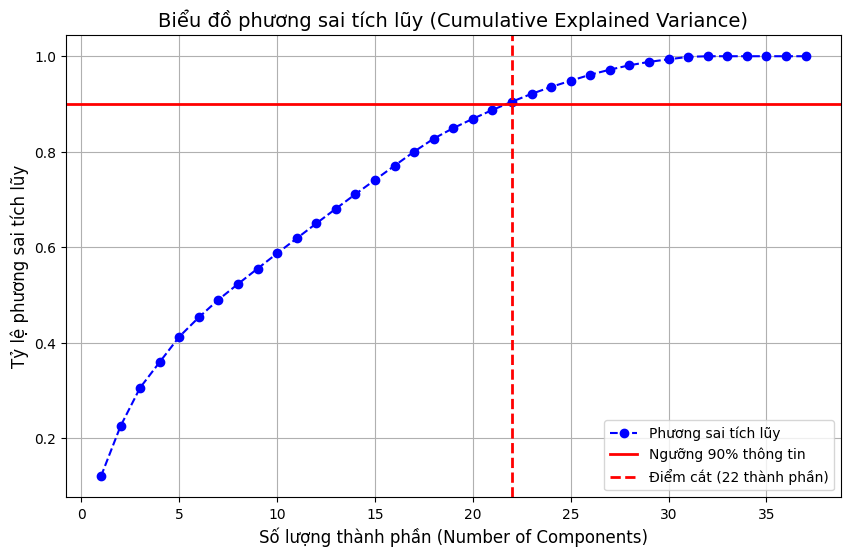

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Giả sử df_input là dữ liệu đầu vào của bạn
# ---------------------------------------------------------
# BƯỚC 1: Chạy PCA để tính toán phương sai tích lũy
# ---------------------------------------------------------

pca_check = PCA()
pca_check.fit(df_input)

# Tính phương sai tích lũy (Cumulative Explained Variance)
cumsum = pca_check.explained_variance_ratio_.cumsum()

# Tìm số lượng thành phần cần thiết để đạt >= 90% thông tin (ngưỡng 0.9)
# np.argmax sẽ trả về chỉ số đầu tiên thỏa mãn điều kiện
k_90 = np.argmax(cumsum >= 0.9) + 1 

print(f"Số lượng thành phần cần thiết để giữ lại 90% thông tin: {k_90} thành phần")
print(f"Lượng thông tin thực tế giữ lại được: {cumsum[k_90-1]:.4f} (hay {cumsum[k_90-1]*100:.2f}%)")

# ---------------------------------------------------------
# BƯỚC 2: Vẽ biểu đồ chuyên nghiệp với đường gióng 90%
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

# Vẽ đường biểu diễn phương sai tích lũy
plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='--', color='b', label='Phương sai tích lũy')

# Vẽ đường ngang màu đỏ tại mức 90% (Threshold)
plt.axhline(y=0.9, color='r', linestyle='-', linewidth=2, label='Ngưỡng 90% thông tin')

# Vẽ đường dọc màu đỏ tại vị trí k_90
plt.axvline(x=k_90, color='r', linestyle='--', linewidth=2, label=f'Điểm cắt ({k_90} thành phần)')

# Trang trí biểu đồ
plt.title('Biểu đồ phương sai tích lũy (Cumulative Explained Variance)', fontsize=14)
plt.xlabel('Số lượng thành phần (Number of Components)', fontsize=12)
plt.ylabel('Tỷ lệ phương sai tích lũy', fontsize=12)
plt.xticks(np.arange(0, len(cumsum)+1, step=5)) # Chỉnh bước nhảy trục X cho dễ nhìn
plt.grid(True)
plt.legend(loc='best')

# Hiển thị biểu đồ
plt.show()

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# BƯỚC 1: Biến đổi dữ liệu gốc sang 22 chiều (theo kết quả đã tìm)
# ---------------------------------------------------------

# Khởi tạo PCA với 22 thành phần
pca_final = PCA(n_components=22)

# Tạo bộ dữ liệu mới (df_pca_22) từ dữ liệu đầu vào
df_pca_22 = pca_final.fit_transform(df_input)

print(f"Kích thước dữ liệu sau giảm chiều: {df_pca_22.shape}") 
# Kết quả mong đợi: (số dòng, 22)

Kích thước dữ liệu sau giảm chiều: (22114, 22)


--------------------------------------------------
Đang tạo các Silhouette Plot trên dữ liệu PCA...


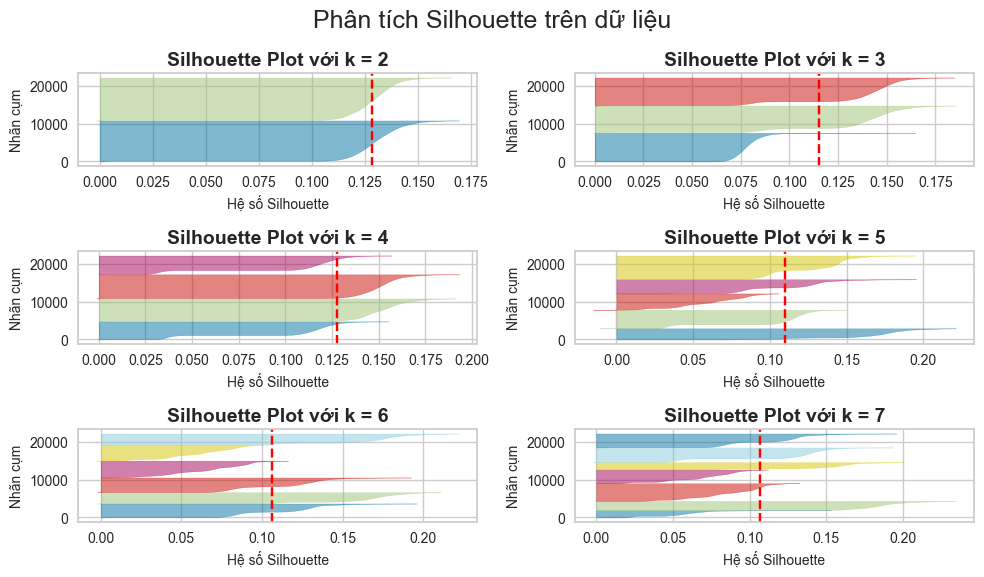

In [59]:
from yellowbrick.cluster import SilhouetteVisualizer

#==========================================
# PHẦN 2: SILHOUETTE ANALYSIS (TÌM K)
# ==========================================

# Cấu hình các giá trị k muốn thử
k_values_to_plot = [2, 3, 4, 5, 6, 7]

fig, axes = plt.subplots(3, 2, figsize=(10, 6)) 
axes = axes.flatten()

print("-" * 50)
print("Đang tạo các Silhouette Plot trên dữ liệu PCA...")

for i, k in enumerate(k_values_to_plot):
    # 2.1 Khởi tạo mô hình K-Means
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # 2.2 Khởi tạo Visualizer
    # force_model=True: Sửa lỗi tương thích Yellowbrick với scikit-learn mới
    visualizer = SilhouetteVisualizer(
        model, 
        colors='yellowbrick', 
        ax=axes[i], 
        force_model=True 
    )
    
    # 2.3 Fit dữ liệu 
    # QUAN TRỌNG: Ở đây ta dùng data_pca (dữ liệu sau khi giảm chiều)
    # Nếu bạn muốn dùng dữ liệu gốc, hãy đổi 'data_pca' thành 'df_input'
    visualizer.fit(df_pca_22)
    
    # 2.4 Trang trí
    axes[i].set_title(f'Silhouette Plot với k = {k}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Hệ số Silhouette", fontsize=10)
    axes[i].set_ylabel("Nhãn cụm", fontsize=10)

# Ẩn ô cuối cùng (ô thứ 8) vì ta chỉ vẽ 7 biểu đồ
if len(k_values_to_plot) < len(axes):
    for j in range(len(k_values_to_plot), len(axes)):
        axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle(f"Phân tích Silhouette trên dữ liệu", fontsize=18, y=0.99)
plt.show()

In [61]:
# Chọn số cụm chốt hạ (Ví dụ k=4)
k_final = 4

# k-means++ -> solution 2
# https://users.soict.hust.edu.vn/khoattq/ml-dm-course/L4-Kmeans.pdf

# Khởi tạo và train model
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_pca_22)

# QUAN TRỌNG: Gán nhãn cụm vào DataFrame
# Lưu ý: Nên gán vào DataFrame GỐC (chưa scale) để dễ đọc hiểu con số
# Giả sử df_original là dữ liệu ban đầu trước khi scale
df_original_10 = df.copy() # Hoặc tên biến chứa dữ liệu gốc của bạn
df_original_10['Cluster_Label'] = clusters

print(f"Đã phân cụm xong. Các nhãn: {pd.unique(clusters)}")
# Xem thử 5 dòng đầu
print(df_original_10[['Cluster_Label']].head())

Đã phân cụm xong. Các nhãn: [2 1 3 0]
   Cluster_Label
0              2
1              1
2              2
3              1
4              3


In [63]:
from sklearn.metrics import silhouette_score

# --- 4.7. ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM ---

# 1. Tính toán Inertia (WSSSE - Within Set Sum of Squared Errors)
# Đây là tổng bình phương khoảng cách từ các mẫu đến tâm cụm tương ứng[cite: 211, 227].
wssse = kmeans_final.inertia_

# 2. Tính toán Silhouette Score trung bình
# Chỉ số này đo lường độ tách biệt giữa các cụm, giá trị càng gần 1 càng tốt[cite: 230, 243].
# Lưu ý: Tính toán trên không gian dữ liệu PCA (df_pca_22) là nơi thuật toán hoạt động.
silhouette_avg = silhouette_score(df_pca_22, clusters)

# 3. Thống kê phân bổ số lượng khách hàng trong từng cụm
cluster_counts = df_original_10['Cluster_Label'].value_counts().sort_index()


print(f"1. Chỉ số Inertia (WSSSE):          {wssse:,.2f}")
print(f"2. Hệ số Silhouette trung bình:    {silhouette_avg:.4f}")
print("\n3. Phân bổ khách hàng theo từng cụm:")

for cluster_id, count in cluster_counts.items():
    percentage = (count / len(df_original_10)) * 100
    print(f"   - Cụm {cluster_id}: {count:>5} khách hàng ({percentage:>5.2f}%)")

print("-" * 50)



1. Chỉ số Inertia (WSSSE):          61,881.18
2. Hệ số Silhouette trung bình:    0.1274

3. Phân bổ khách hàng theo từng cụm:
   - Cụm 0:  4745 khách hàng (21.46%)
   - Cụm 1:  6052 khách hàng (27.37%)
   - Cụm 2:  6351 khách hàng (28.72%)
   - Cụm 3:  4966 khách hàng (22.46%)
--------------------------------------------------


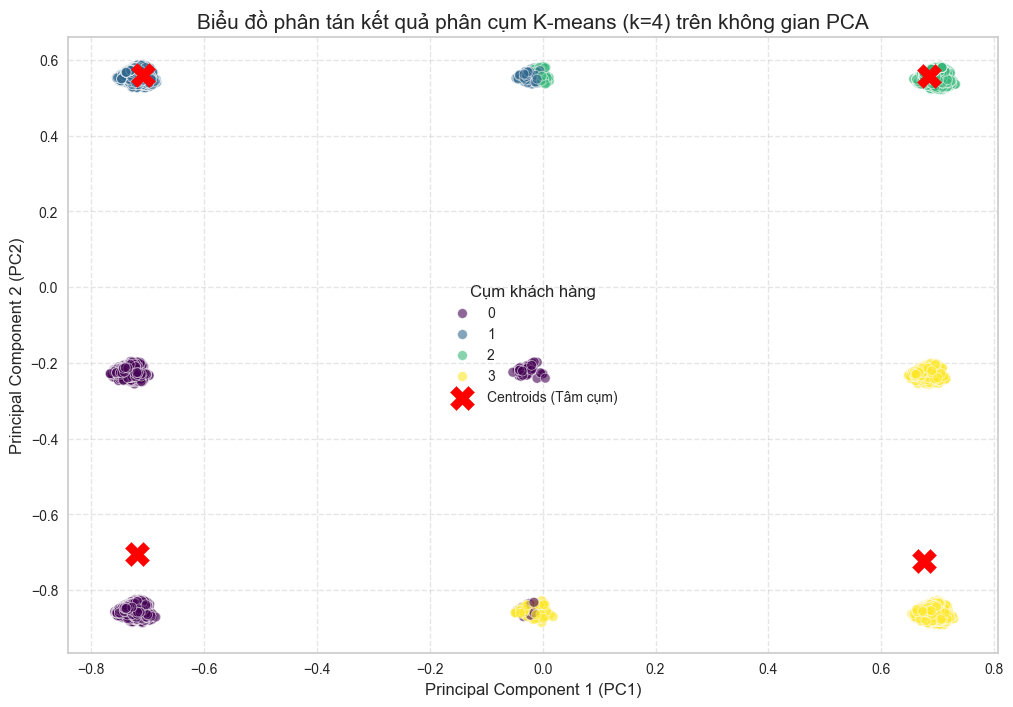

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Bước 4.8: Trực quan hóa kết quả phân cụm trên không gian PCA ---

# 1. Chuẩn bị dữ liệu vẽ
# Lấy 2 thành phần chính đầu tiên (PC1, PC2) từ dữ liệu PCA
# df_pca_22 có thể là numpy array hoặc DataFrame tùy bước trước, 
# code dưới đây xử lý an toàn cho cả 2 trường hợp.
if isinstance(df_pca_22, pd.DataFrame):
    pca_vis = df_pca_22.iloc[:, :2].values
else:
    pca_vis = df_pca_22[:, :2]

# Tạo DataFrame tạm để dùng cho Seaborn
df_vis = pd.DataFrame(data=pca_vis, columns=['PC1', 'PC2'])
df_vis['Cluster'] = clusters  # Gán nhãn cụm từ kết quả K-means

# 2. Lấy tọa độ tâm cụm (Centroids)
# Lưu ý: Tâm cụm nằm trong không gian PCA
centroids = kmeans_final.cluster_centers_

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 8))

# Vẽ các điểm dữ liệu
sns.scatterplot(
    data=df_vis, x='PC1', y='PC2', 
    hue='Cluster', palette='viridis', 
    alpha=0.6, s=50, legend='full'
)

# Vẽ các tâm cụm (Centroids)
plt.scatter(
    centroids[:, 0], centroids[:, 1], 
    s=300, c='red', marker='X', label='Centroids (Tâm cụm)'
)

# Trang trí biểu đồ
plt.title('Biểu đồ phân tán kết quả phân cụm K-means (k=4) trên không gian PCA', fontsize=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Cụm khách hàng')
plt.grid(True, linestyle='--', alpha=0.5)

# Hiển thị
plt.show()

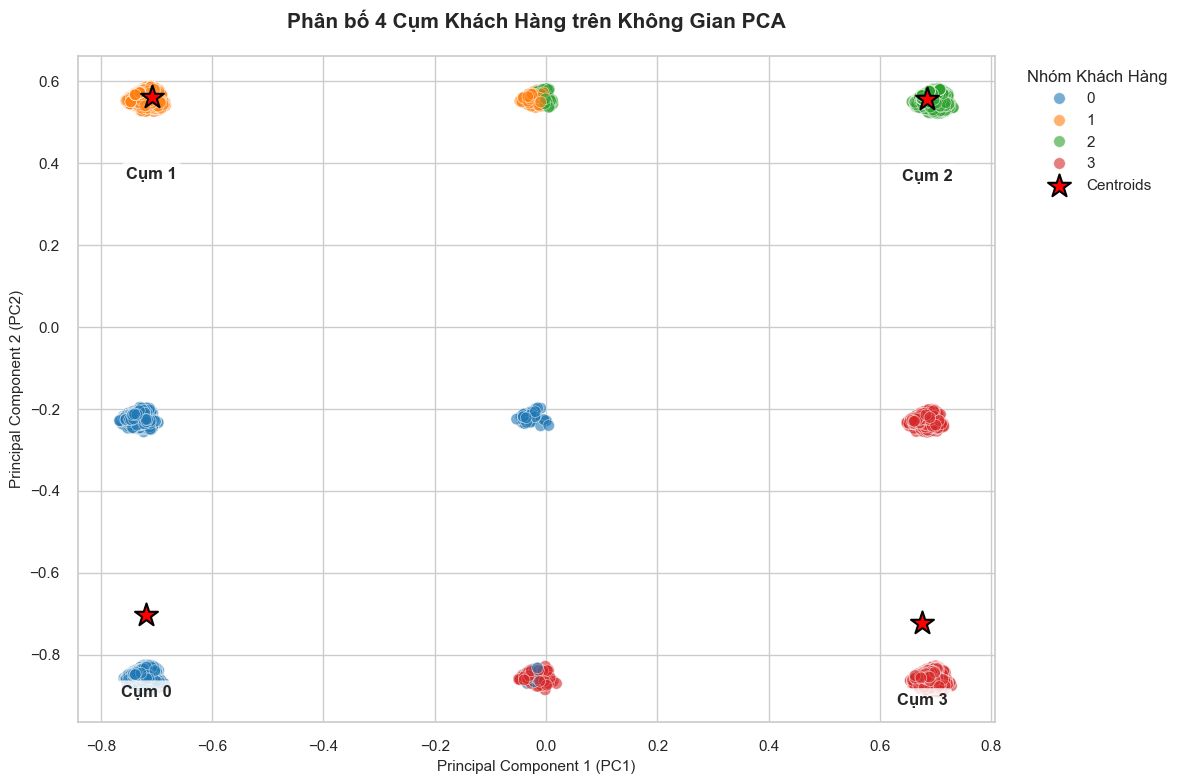

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử bạn đã có df_pca_plot và kmeans_final

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Vẽ các điểm dữ liệu (Points)
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    data=df_pca_plot, 
    palette='tab10', 
    s=70, alpha=0.6, edgecolor='w', linewidth=0.5
)

# 2. Vẽ tâm cụm (Centroids)
centroids = kmeans_final.cluster_centers_

# Lưu ý: Chỉ vẽ toạ độ của 2 chiều đầu tiên (cột 0 và 1)
plt.scatter(
    centroids[:, 0], centroids[:, 1], 
    c='red', s=300, marker='*', 
    edgecolors='black', linewidths=1.5,
    label='Centroids', zorder=10
)

# 3. Gắn nhãn số cụm (ĐÃ SỬA LỖI Ở ĐÂY)
# ---------------------------------------------------------
# Chúng ta dùng slicing [:, :2] để chỉ lấy 2 cột đầu tiên của centroids
# để khớp với trục PC1 và PC2 đang vẽ.
for i, (cx, cy) in enumerate(centroids[:, :2]):  # <--- FIX: Thêm [:, :2]
    plt.text(
        cx, cy - 0.2, 
        f'Cụm {i}', 
        fontsize=12, fontweight='bold', ha='center', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round')
    )
# ---------------------------------------------------------

# 4. Trang trí trục và tiêu đề
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)
plt.title('Phân bố 4 Cụm Khách Hàng trên Không Gian PCA', fontsize=15, fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Nhóm Khách Hàng')

plt.tight_layout()
plt.show()

In [58]:
# 1. Chọn các cột số bạn muốn phân tích sâu
cols_to_describe = ['Age', 'Total_Amount', 'Quantity', 'Session_Duration_Minutes', 'Customer_Rating']

# 2. Sử dụng groupby, tính describe và thêm .round(2) ở cuối
cluster_stats_detailed = df_original_10.groupby('Cluster_Label')[cols_to_describe].describe().round(2)

# 3. Xoay bảng để dễ nhìn hơn
final_view = cluster_stats_detailed.stack(level=0)

print("BẢNG THỐNG KÊ CHI TIẾT ĐẶC TRƯNG TỪNG CỤM")
display(final_view)


BẢNG THỐNG KÊ CHI TIẾT ĐẶC TRƯNG TỪNG CỤM


/var/folders/p6/fth8lbts7y3b2m7w7_vqght40000gn/T/ipykernel_21392/1345631145.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  final_view = cluster_stats_detailed.stack(level=0)


count     mean      std    min  \
Cluster_Label                                                             
0             Age                       4745.0    35.11    10.70  18.00   
              Customer_Rating           4745.0     3.89     1.13   1.00   
              Quantity                  4745.0     2.80     1.46   1.00   
              Session_Duration_Minutes  4745.0    14.56     4.87   1.00   
              Total_Amount              4745.0  1214.55  2300.30   7.00   
1             Age                       6052.0    35.12    10.97  18.00   
              Customer_Rating           6052.0     3.90     1.13   1.00   
              Quantity                  6052.0     2.84     1.46   1.00   
              Session_Duration_Minutes  6052.0    14.47     4.85   1.00   
              Total_Amount              6052.0  1186.15  2292.57  11.02   
2             Age                       6351.0    34.92    11.30  18.00   
              Customer_Rating           6351.0     3.90     1.13   1.00   
              Quantity                  6351.0     2.82     1.45   1.00   
              Session_Duration_Minutes  6351.0    14.60     5.80   1.00   
              Total_Amount              6351.0  1207.92  2282.70   6.21   
3             Age                       4966.0    34.70    11.11  18.00   
              Customer_Rating           4966.0     3.90     1.12   1.00   
              Quantity                  4966.0     2.85     1.45   1.00   
              Session_Duration_Minutes  4966.0    14.68     4.93   1.00   
              Total_Amount              4966.0  1226.82  2164.43   7.59   

                                           25%     50%      75%       max  
Cluster_Label                                                              
0             Age                        27.00   35.00    42.00     75.00  
              Customer_Rating             3.00    4.00     5.00      5.00  
              Quantity                    1.00    3.00     4.00      5.00  
              Session_Duration_Minutes   12.00   14.00    17.00     55.00  
              Total_Amount              152.59  432.55  1160.94  25562.10  
1             Age                        27.00   35.00    42.00     75.00  
              Customer_Rating             3.00    4.00     5.00      5.00  
              Quantity                    1.00    3.00     4.00      5.00  
              Session_Duration_Minutes   12.00   14.00    17.00     73.00  
              Total_Amount              162.18  415.92  1140.07  37852.05  
2             Age                        26.00   34.00    43.00     73.00  
              Customer_Rating             3.00    4.00     5.00      5.00  
              Quantity                    1.00    3.00     4.00      5.00  
              Session_Duration_Minutes   12.00   14.00    17.00     78.00  
              Total_Amount              161.10  436.62  1194.06  29045.35  
3             Age                        26.00   34.00    42.00     72.00  
              Customer_Rating             3.00    4.00     5.00      5.00  
              Quantity                    1.00    3.00     4.00      5.00  
              Session_Duration_Minutes   12.00   14.00    17.00     57.00  
              Total_Amount              161.77  428.37  1295.93  24391.45

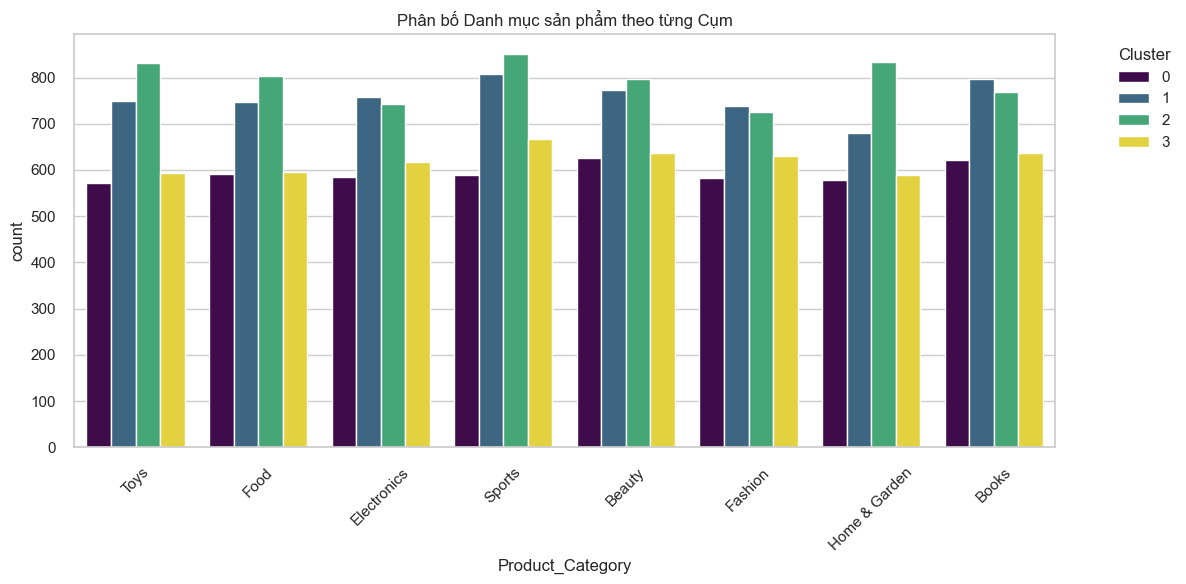

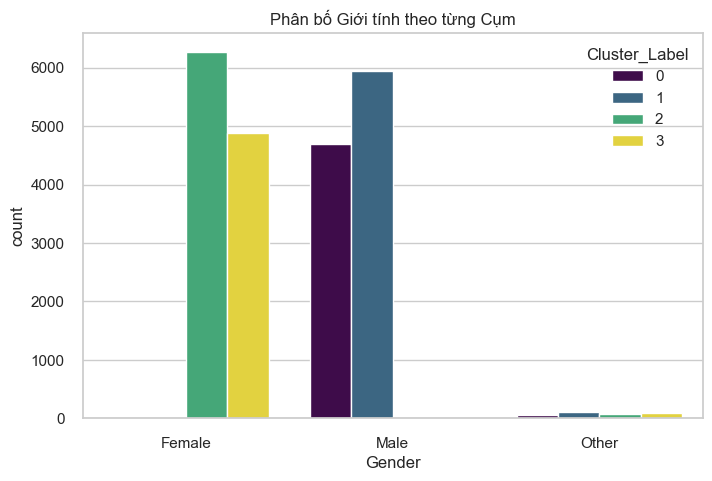

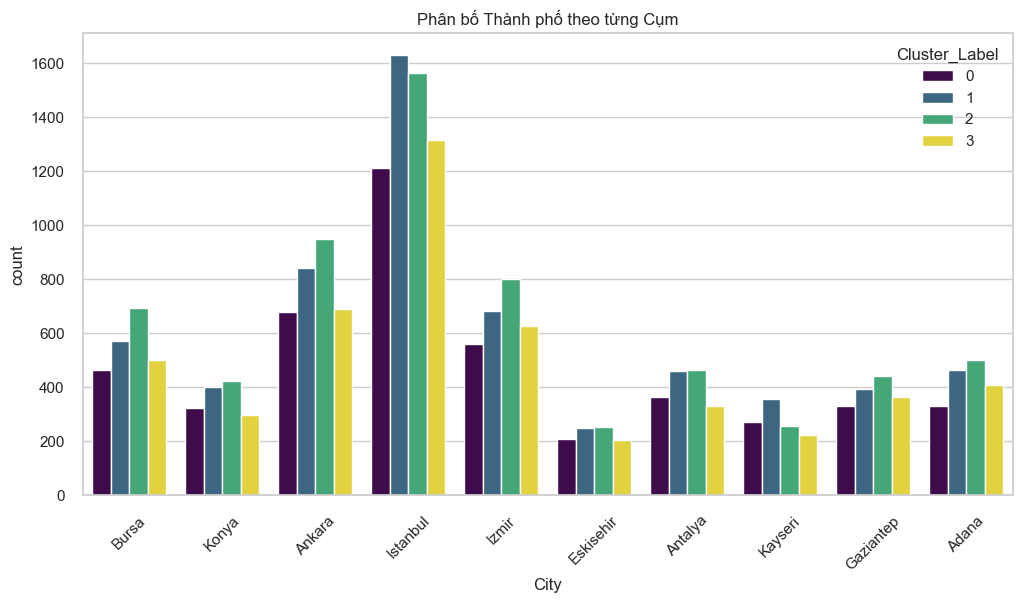

In [62]:
# Giả sử df_original_10 là dataframe đã có cột 'Cluster_Label'
# Ta sẽ xem mỗi cụm thích mua Category nào nhất và sống ở đâu

# 1. Xem phân bố Danh mục sản phẩm theo cụm
plt.figure(figsize=(12, 6))
sns.countplot(data=df_original_10, x='Product_Category', hue='Cluster_Label', palette='viridis')
plt.title('Phân bố Danh mục sản phẩm theo từng Cụm')
plt.xticks(rotation=45)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Xem phân bố Giới tính theo cụm
plt.figure(figsize=(8, 5))
sns.countplot(data=df_original_10, x='Gender', hue='Cluster_Label', palette='viridis')
plt.title('Phân bố Giới tính theo từng Cụm')
plt.show()

# 3. Xem phân bố Thành phố theo cụm
plt.figure(figsize=(12, 6))
sns.countplot(data=df_original_10, x='City', hue='Cluster_Label', palette='viridis')
plt.title('Phân bố Thành phố theo từng Cụm')
plt.xticks(rotation=45)
plt.show()

# Phướng pháp DBSCAN

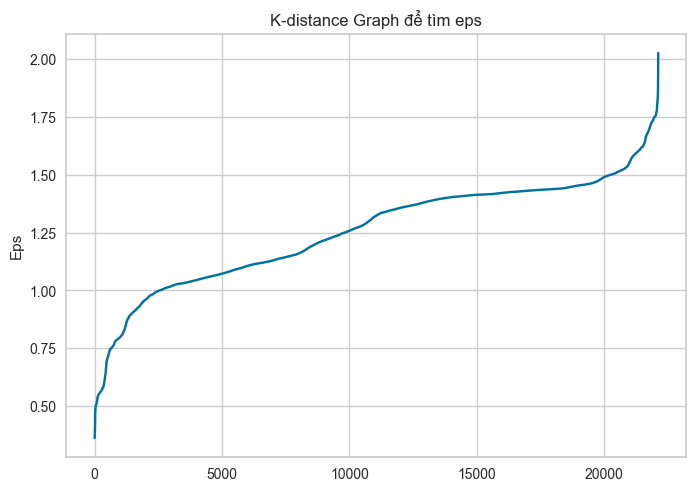

In [76]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 1. Tìm eps tối ưu bằng K-distance graph
neighbors = NearestNeighbors(n_neighbors=44) # min_samples thường chọn 2*dim
neighbors_fit = neighbors.fit(df_pca_22) # pca_df là dữ liệu sau PCA
distances, indices = neighbors_fit.kneighbors(df_pca_22)
distances = np.sort(distances[:, 43], axis=0)
plt.plot(distances)
plt.title('K-distance Graph để tìm eps')
plt.ylabel('Eps')
plt.show()


In [78]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

dbscan_model = DBSCAN(eps=0.55, min_samples=44)
dbscan_labels = dbscan_model.fit_predict(df_pca_22)


cols = [f"PC{i+1}" for i in range(df_pca_22.shape[1])]
df_dbscan = pd.DataFrame(df_pca_22, columns=cols)

# Bây giờ bạn có thể gán cột mới bình thường
df_dbscan['Cluster_DBSCAN'] = dbscan_labels

# --- PHẦN 3: THỐNG KÊ VÀ ĐÁNH GIÁ ---

# 4. Tính toán số lượng cụm và nhiễu
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)
noise_ratio = n_noise_ / len(dbscan_labels) * 100

print("-" * 30)
print("KẾT QUẢ PHÂN CỤM DBSCAN")
print("-" * 30)
print(f"Số lượng cụm tìm được (không tính nhiễu): {n_clusters_}")
print(f"Số lượng điểm nhiễu (Noise - Label -1): {n_noise_}")
print(f"Tỷ lệ nhiễu: {noise_ratio:.2f}%")

# 5. Tính Silhouette Score để so sánh với K-means
# Lưu ý: Việc tính toán này có thể tốn thời gian nếu dữ liệu lớn (>20k dòng)
if n_clusters_ > 0:
    print("Đang tính Silhouette Score...")
    sil_score = silhouette_score(df_pca_22, dbscan_labels)
    print(f"Silhouette Score: {sil_score:.4f}")
else:
    print("Không đủ cụm để tính Silhouette Score.")

# 6. Xem mẫu kết quả
print("\n5 dòng đầu tiên của dữ liệu sau phân cụm:")
print(df_dbscan[['PC1', 'PC2', 'Cluster_DBSCAN']].head())

------------------------------
KẾT QUẢ PHÂN CỤM DBSCAN
------------------------------
Số lượng cụm tìm được (không tính nhiễu): 11
Số lượng điểm nhiễu (Noise - Label -1): 21449
Tỷ lệ nhiễu: 96.99%
Đang tính Silhouette Score...
Silhouette Score: -0.2072

5 dòng đầu tiên của dữ liệu sau phân cụm:
        PC1       PC2  Cluster_DBSCAN
0  0.707788  0.579917              -1
1 -0.730477  0.571993              -1
2  0.687583  0.567358              -1
3 -0.746102  0.549586              -1
4  0.686432 -0.861430              -1


In [37]:
# Chạy thử vòng lặp để tìm eps tốt hơn
for ep in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    db = DBSCAN(eps=ep, min_samples=44)
    labels = db.fit_predict(df_pca_22)
    
    n_noise = list(labels).count(-1)
    noise_rate = n_noise / len(labels) * 100
    
    # Chỉ in ra nếu tỷ lệ nhiễu < 80% (đỡ rác màn hình)
    if noise_rate < 80:
        print(f"Eps: {ep} | Tỷ lệ nhiễu: {noise_rate:.2f}% | Số cụm: {len(set(labels))-1}")

Eps: 1.0 | Tỷ lệ nhiễu: 57.57% | Số cụm: 42
Eps: 1.5 | Tỷ lệ nhiễu: 0.12% | Số cụm: 1
Eps: 2.0 | Tỷ lệ nhiễu: 0.00% | Số cụm: 0
Eps: 2.5 | Tỷ lệ nhiễu: 0.00% | Số cụm: 0
Eps: 3.0 | Tỷ lệ nhiễu: 0.00% | Số cụm: 0


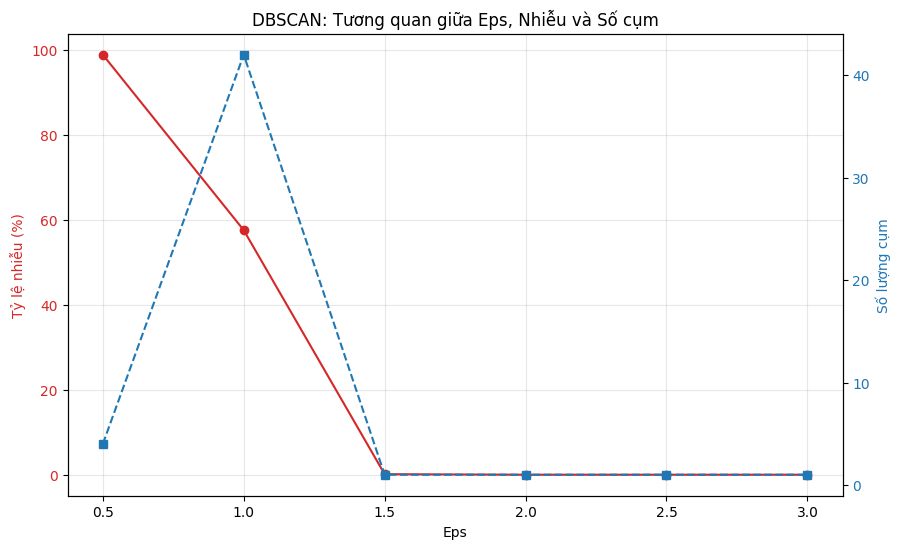

In [41]:
import matplotlib.pyplot as plt

eps_list = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
noise_rates = []
n_clusters_list = []

for ep in eps_list:
    db = DBSCAN(eps=ep, min_Zsamples=44)
    labels = db.fit_predict(df_pca_22)
    
    # Tính toán
    n_noise = list(labels).count(-1)
    noise_rate = n_noise / len(labels) * 100
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    noise_rates.append(noise_rate)
    n_clusters_list.append(n_clusters)

# --- VISUALIZATION ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục Y bên trái: Tỷ lệ nhiễu
color = 'tab:red'
ax1.set_xlabel('Eps')
ax1.set_ylabel('Tỷ lệ nhiễu (%)', color=color)
ax1.plot(eps_list, noise_rates, color=color, marker='o', label='Nhiễu (%)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Trục Y bên phải: Số lượng cụm
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Số lượng cụm', color=color)  
ax2.plot(eps_list, n_clusters_list, color=color, marker='s', linestyle='--', label='Số cụm')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('DBSCAN: Tương quan giữa Eps, Nhiễu và Số cụm')
plt.show()

In [49]:
import numpy as np

for ep in np.arange(1.0, 1.5, 0.05):
    db = DBSCAN(eps=ep, min_samples=44)
    labels = db.fit_predict(df_pca_22)
    
    n_noise = list(labels).count(-1)
    noise_rate = n_noise / len(labels) * 100
    
    print(f"Eps: {ep} | Tỷ lệ nhiễu: {noise_rate:.2f}% | Số cụm: {len(set(labels))-1}")

Eps: 1.0 | Tỷ lệ nhiễu: 57.57% | Số cụm: 42
Eps: 1.05 | Tỷ lệ nhiễu: 33.02% | Số cụm: 35
Eps: 1.1 | Tỷ lệ nhiễu: 22.64% | Số cụm: 25
Eps: 1.1500000000000001 | Tỷ lệ nhiễu: 17.85% | Số cụm: 24
Eps: 1.2000000000000002 | Tỷ lệ nhiễu: 14.90% | Số cụm: 22
Eps: 1.2500000000000002 | Tỷ lệ nhiễu: 12.06% | Số cụm: 18
Eps: 1.3000000000000003 | Tỷ lệ nhiễu: 9.81% | Số cụm: 17
Eps: 1.3500000000000003 | Tỷ lệ nhiễu: 7.53% | Số cụm: 13
Eps: 1.4000000000000004 | Tỷ lệ nhiễu: 5.16% | Số cụm: 6
Eps: 1.4500000000000004 | Tỷ lệ nhiễu: 0.54% | Số cụm: 1


In [51]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

dbscan_model = DBSCAN(eps=1.4, min_samples=44)
dbscan_labels = dbscan_model.fit_predict(df_pca_22)


cols = [f"PC{i+1}" for i in range(df_pca_22.shape[1])]
df_dbscan = pd.DataFrame(df_pca_22, columns=cols)

# Bây giờ bạn có thể gán cột mới bình thường
df_dbscan['Cluster_DBSCAN'] = dbscan_labels

# --- PHẦN 3: THỐNG KÊ VÀ ĐÁNH GIÁ ---

# 4. Tính toán số lượng cụm và nhiễu
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)
noise_ratio = n_noise_ / len(dbscan_labels) * 100

print("-" * 30)
print("KẾT QUẢ PHÂN CỤM DBSCAN")
print("-" * 30)
print(f"Số lượng cụm tìm được (không tính nhiễu): {n_clusters_}")
print(f"Số lượng điểm nhiễu (Noise - Label -1): {n_noise_}")
print(f"Tỷ lệ nhiễu: {noise_ratio:.2f}%")

# 5. Tính Silhouette Score để so sánh với K-means
# Lưu ý: Việc tính toán này có thể tốn thời gian nếu dữ liệu lớn (>20k dòng)
if n_clusters_ > 0:
    print("Đang tính Silhouette Score...")
    sil_score = silhouette_score(df_pca_22, dbscan_labels)
    print(f"Silhouette Score: {sil_score:.4f}")
else:
    print("Không đủ cụm để tính Silhouette Score.")

# 6. Xem mẫu kết quả
print("\n5 dòng đầu tiên của dữ liệu sau phân cụm:")
print(df_dbscan[['PC1', 'PC2', 'Cluster_DBSCAN']].head())

------------------------------
KẾT QUẢ PHÂN CỤM DBSCAN
------------------------------
Số lượng cụm tìm được (không tính nhiễu): 6
Số lượng điểm nhiễu (Noise - Label -1): 1140
Tỷ lệ nhiễu: 5.16%
Đang tính Silhouette Score...
Silhouette Score: 0.0390

5 dòng đầu tiên của dữ liệu sau phân cụm:
        PC1       PC2  Cluster_DBSCAN
0  0.707788  0.579917               0
1 -0.730477  0.571993               0
2  0.687583  0.567358               0
3 -0.746102  0.549586               0
4  0.686432 -0.861430               1


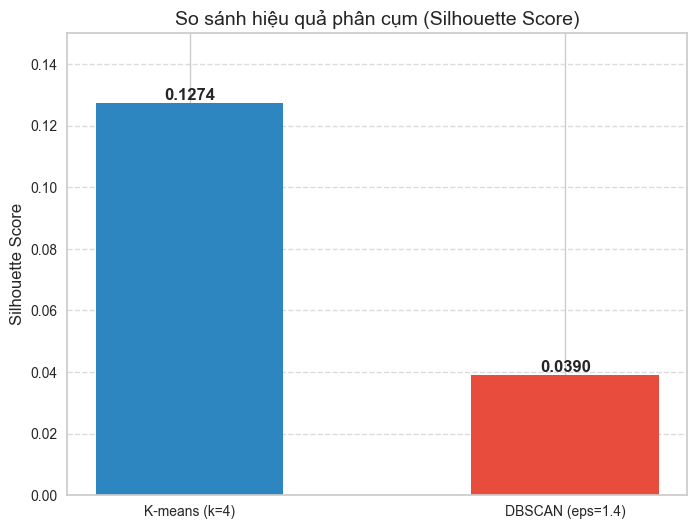

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

# Dữ liệu so sánh từ kết quả thực nghiệm của bạn
methods = ['K-means (k=4)', 'DBSCAN (eps=1.4)']
scores = [0.1274, 0.0390]

# Thiết lập biểu đồ
plt.figure(figsize=(8, 6))
bars = plt.bar(methods, scores, color=['#2E86C1', '#E74C3C'], width=0.5)

# Thêm số liệu trên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('So sánh hiệu quả phân cụm (Silhouette Score)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=12)
plt.ylim(0, 0.15) # Giới hạn trục Y cao hơn một chút để số liệu không bị cắt
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()